# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>Car Price Prediction Project</b></p>

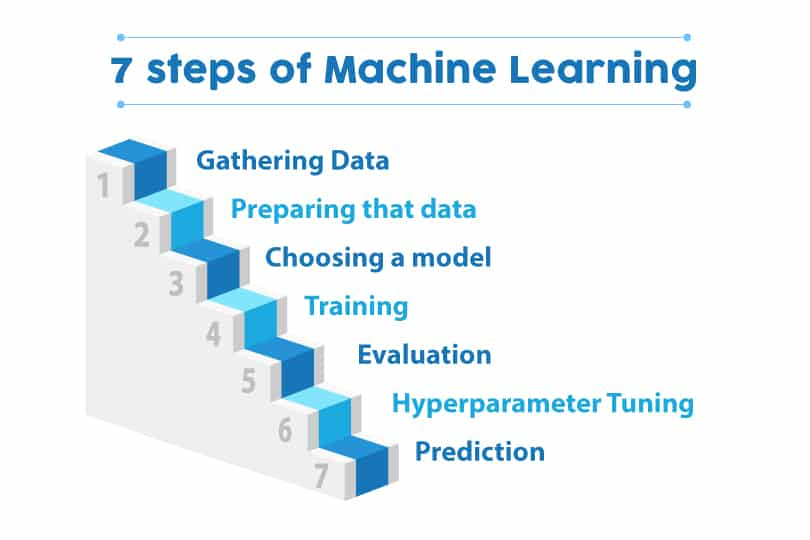

# Data set overview and cleaning

## import necessary libraries

In [1]:
# Import data analysis libraries
import numpy as np
import pandas as pd
# import data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (10, 6)  # to fix the figure size
# ignore the warnings
import warnings
warnings.filterwarnings('ignore')

# importing necessary ml libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler #for scaling
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # evaluation metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, KFold # cross validation and split

## About the Dataset

This dataset contains information about used vehicles, including their specifications, ownership history, and selling prices.

1. **name**: Contains the make, brand, and model name of each vehicle.

2. **year**: Indicates the manufacturing or model year of the vehicle.

3. **selling_price**: Represents the selling price of the vehicle.

4. **km_driven**: Indicates the total distance, in kilometers, that the vehicle has been driven.

5. **fuel**: Specifies the type of fuel used by the vehicle, such as petrol, diesel, CNG, LPG, or electric.

6. **seller_type**: Indicates the type of seller offering the vehicle for sale, such as an individual, dealer, or trustmark dealer.

7. **transmission**: Specifies the type of transmission used by the vehicle, such as manual or automatic.

8. **owner**: Contains information about the ownership history of the vehicle, indicating whether it has had a first, second, third, or subsequent owner.

9. **mileage**: Indicates the fuel efficiency of the vehicle, typically expressed as the distance it can travel per liter of fuel.

10. **engine**: Represents the engine capacity of the vehicle, typically measured in cubic centimeters (CC).

11. **max_power**: Indicates the maximum power produced by the vehicle's engine, typically measured in brake horsepower (bhp).

12. **torque**: Represents the rotational force produced by the engine. It is usually expressed in Newton-meters (Nm) or kilogram-meters (kgm) at a particular engine speed (RPM).

13. **seats**: Indicates the total number of seats available in the vehicle.


In [2]:
df = pd.read_csv('Cars.csv')
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.shape
# 8128 rows and 13 columns

(8128, 13)

In [5]:
df.info()
# while some of the features has int and float data type, majority has str data type.
# there are columns like mileage, engine and max power, that despite containing numeric information, it is set to str data type, so it will need some cleaning.
# torque column, need to be split to get real information!!.
# null values present in mileage, engine, max power, torque and seats!

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [6]:
df.describe().T
# just by comparing the mean and standard deviation for selling price and km driven columns, we can see that there are outliers in these 
# columns, and can be verified by comparing the q3 or 75% and max value of these columns, the difference between them is huge.

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
seats,7907.0,5.416719,0.959588,2.0,5.0,5.0,5.0,14.0


In [7]:
df.describe(include = 'str')

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,8128,8128,8128,8128,8128,7907,7907,7913,7906
unique,2058,4,3,2,5,393,121,322,441
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,129,4402,6766,7078,5289,225,1017,377,530


In [8]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

## Necessary tasks for cleaning and imputation

### For the feature owner, map First owner to 1, ..., Test Drive Car to 5

In [9]:
df.owner.value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [10]:
owner_mapping = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

df['owner'] = df['owner'].map(owner_mapping)
df.owner.value_counts()

owner
1    5289
2    2105
3     555
4     174
5       5
Name: count, dtype: int64

In [11]:
df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0


### For the feature fuel, remove all rows with CNG and LPG because CNG and LPG use a different mileage system i.e., km/kg which is different from kmpl for Diesel and Petrol

In [12]:
df.fuel.value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [13]:
df.groupby(['fuel', 'mileage'])['fuel'].count()

fuel    mileage    
CNG     10.9 km/kg      1
        11.88 km/kg     1
        13.2 km/kg      3
        15.1 km/kg      1
        20.88 km/kg     1
                       ..
Petrol  25.4 kmpl      13
        26.0 kmpl       7
        42.0 kmpl       1
        9.0 kmpl        2
        9.5 kmpl        6
Name: fuel, Length: 482, dtype: int64

In [14]:
df.groupby('fuel')['mileage'].unique().apply(lambda x: x[:5])
# as the number of CNG and LPG cars are very few compared to Diesel and Petrol, the model may not learn it's affect on the 
# target variable as there isn't enough data to learn from, and the mileage values corresponding to CNG and LPG vehicles has a different
# unite than Diesel and Petrol vehicles, so it adds another unit conversion load for us, so we are planning to drop these values.

fuel
CNG       [33.44 km/kg, 26.6 km/kg, 20.88 km/kg, 30.46 k...
Diesel    [23.4 kmpl, 21.14 kmpl, 23.0 kmpl, 23.59 kmpl,...
LPG       [17.3 km/kg, 26.2 km/kg, 13.45 km/kg, nan, 19....
Petrol    [17.7 kmpl, 16.1 kmpl, 20.14 kmpl, 17.3 kmpl, ...
Name: mileage, dtype: object

In [15]:
df = df[~df['fuel'].isin(['CNG', 'LPG'])]
df['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
Name: count, dtype: int64

### For the feature mileage, remove “kmpl” and convert the column to numerical type (e.g., float).

In [16]:
df['mileage'] = df['mileage'].str.split().str[0].astype(float)
print(df.head(2))

                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   

  seller_type transmission  owner  mileage   engine   max_power  \
0  Individual       Manual      1    23.40  1248 CC      74 bhp   
1  Individual       Manual      2    21.14  1498 CC  103.52 bhp   

                torque  seats  
0       190Nm@ 2000rpm    5.0  
1  250Nm@ 1500-2500rpm    5.0  


In [17]:
df.mileage.dtype

dtype('float64')

### For the feature engine, remove “CC” and convert the column to numerical type (e.g., float), and do the same for max power!!

In [18]:
df.engine.value_counts()
# all the values seem to have CC str after numeric values so they need to be stripped of the unnecessary str at the end.

engine
1248 CC    1017
1197 CC     832
796 CC      432
998 CC      424
2179 CC     389
           ... 
2650 CC       1
2446 CC       1
3498 CC       1
2776 CC       1
1950 CC       1
Name: count, Length: 121, dtype: int64

In [19]:
df['engine'] = df['engine'].str.split().str[0].astype(float)
print(df.head(2))
print(df.engine.dtype)

                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   

  seller_type transmission  owner  mileage  engine   max_power  \
0  Individual       Manual      1    23.40  1248.0      74 bhp   
1  Individual       Manual      2    21.14  1498.0  103.52 bhp   

                torque  seats  
0       190Nm@ 2000rpm    5.0  
1  250Nm@ 1500-2500rpm    5.0  
float64


In [20]:
df.engine

0       1248.0
1       1498.0
2       1497.0
3       1396.0
4       1298.0
         ...  
8123    1197.0
8124    1493.0
8125    1248.0
8126    1396.0
8127    1396.0
Name: engine, Length: 8033, dtype: float64

In [21]:
df.max_power.value_counts()

max_power
74 bhp       377
81.80 bhp    220
88.5 bhp     204
67 bhp       165
46.3 bhp     162
            ... 
161 bhp        1
194 bhp        1
134 bhp        1
203 bhp        1
135.1 bhp      1
Name: count, Length: 309, dtype: int64

In [22]:
df['max_power'] = df['max_power'].str.split().str[0].astype(float)
df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0


In [23]:
df.max_power.dtype

dtype('float64')

### For the feature brand, take only the first word and remove the rest

In [24]:
df.name.value_counts() # we do not need the make, model and too much information about the car, only the brand information is enough

name
Maruti Swift Dzire VDI                          129
Maruti Alto 800 LXI                              82
Maruti Alto LXi                                  71
BMW X4 M Sport X xDrive20d                       62
Maruti Swift VDI                                 61
                                               ... 
Maruti Celerio ZXI AMT BSIV                       1
Tata Bolt Revotron XM                             1
Tata Manza Aura (ABS) Safire BS IV                1
Tata Nexon 1.5 Revotorq XT                        1
Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV      1
Name: count, Length: 2018, dtype: int64

In [25]:
df['brand'] = df['name'].str.split().str[0]
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti


In [26]:
df.brand.value_counts()

brand
Maruti           2378
Hyundai          1393
Mahindra          772
Tata              733
Toyota            488
Honda             467
Ford              397
Renault           228
Chevrolet         228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Kia                 4
Ambassador          4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

### Drop the feature torque, simply because Chaky’s company does not understand well about it

In [27]:
df = df.drop(columns=['torque'])
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


### You will found out that Test Drive Cars are ridiculously expensive. Since we do not want to involve this, we will simply delete all samples related to it.

In [28]:
df.groupby('owner')['selling_price'].mean()

owner
1    7.875987e+05
2    3.958988e+05
3    2.857358e+05
4    2.273088e+05
5    4.403800e+06
Name: selling_price, dtype: float64

In [29]:
df.owner.value_counts()
# we have only 5 test drive cars, and their prices are way more than other cars, to the point that they can be consiered outliers

owner
1    5238
2    2073
3     547
4     170
5       5
Name: count, dtype: int64

In [30]:
df = df[df['owner'] != 5]
df.owner.value_counts()

owner
1    5238
2    2073
3     547
4     170
Name: count, dtype: int64

### drop name and bring brand to beginning

In [31]:
# Drop the name column, as we extracted the brand information from it
df = df.drop(columns=['name'])

# Move brand column to the first position
brand = df.pop('brand')
df.insert(0, 'brand', brand)

# confirm if the data looks the way we want it to:
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


### deal with the null values!!

In [32]:
df.isnull().sum()

brand              0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
dtype: int64

In [33]:
df.groupby(['fuel', 'transmission', 'seats'])['mileage'].mean()

fuel    transmission  seats
Diesel  Automatic     4.0      16.275833
                      5.0      17.676700
                      7.0      13.543431
                      8.0      11.675333
        Manual        2.0       0.000000
                      5.0      22.299424
                      6.0      20.894390
                      7.0      15.957829
                      8.0      13.772872
                      9.0      14.560250
                      10.0     13.429474
                      14.0     10.710000
Petrol  Automatic     4.0      26.925000
                      5.0      18.506889
                      7.0      14.237500
                      8.0      10.750000
        Manual        4.0      17.921239
                      5.0      19.325695
                      6.0      18.272857
                      7.0      17.213846
                      8.0      16.533333
Name: mileage, dtype: float64

In [34]:
df['mileage'].isnull().sum()

np.int64(214)

In [35]:
df['mileage'].isnull().mean() * 100

np.float64(2.665670154459392)

In [36]:
df[df['mileage'].isnull()][['fuel', 'transmission', 'seats', 'mileage']]
# we can see that most of the null values in seats and mileage correspond to same rows, we must check whether all the columns that have
# null values correspond to same rows or cars or not?

,fuel,transmission,seats,mileage
13,Petrol,Manual,NaN,NaN
31,Petrol,Manual,NaN,NaN
78,Diesel,Manual,NaN,NaN
87,Diesel,Manual,NaN,NaN
119,Diesel,Manual,NaN,NaN
...,...,...,...,...
7846,Diesel,Manual,NaN,NaN
7996,Petrol,Manual,NaN,NaN
8009,Petrol,Manual,NaN,NaN
8068,Diesel,Manual,NaN,NaN


In [37]:
df[
    df[['mileage', 'engine', 'max_power', 'seats']]
    .isnull()
    .all(axis=1)
]

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
13,Maruti,2007,200000,80000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN
31,Fiat,2003,70000,50000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN
78,Tata,2003,50000,70000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN
87,Maruti,2015,475000,78000,Diesel,Dealer,Manual,1,NaN,NaN,NaN,NaN
119,Maruti,2010,300000,120000,Diesel,Individual,Manual,2,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
7846,Toyota,2000,200000,100000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN
7996,Hyundai,2000,140000,50000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN
8009,Hyundai,2006,145000,80000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN
8068,Ford,2017,580000,165000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN


The 208 rows identified above have missing values in `mileage`, `engine`, `max_power`, and `seats`. These features are potentially important for predicting the target variable, `selling_price`, and therefore imputing all of them simultaneously could introduce unreliable or misleading values.

If only one feature were missing, it would be more reasonable to estimate the missing value using other available characteristics of similar vehicles. However, because multiple important features are missing for the same vehicles, the first step is to determine what percentage of the overall dataset these rows represent. If the proportion is sufficiently small, removing these rows may be preferable to introducing potentially inaccurate imputations.


In [38]:
missing_rows = df[
    df[['mileage', 'engine', 'max_power', 'seats']]
    .isnull()
    .all(axis=1)
]

percentage = (len(missing_rows) / len(df)) * 100

print(f"Number of rows: {len(missing_rows)}")
print(f"Percentage of dataset: {percentage:.2f}%")

Number of rows: 208
Percentage of dataset: 2.59%


The rows with missing values in `mileage`, `engine`, `max_power`, and `seats` account for approximately **2.59% of the total dataset**. Since this represents a relatively small proportion of the data, removing these rows is considered preferable to imputing multiple important features simultaneously.

Because `mileage`, `engine`, `max_power`, and `seats` may all have a significant relationship with the vehicle's selling price, estimating all of these missing values could introduce unreliable information and negatively affect the performance of the predictive model. Therefore, the rows containing missing values in all four of these features will be removed from the dataset.


In [39]:
df = df.dropna(
    subset=['mileage', 'engine', 'max_power', 'seats'],
    how='all'
)

In [40]:
df.isnull().sum()

brand            0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          6
engine           6
max_power        0
seats            6
dtype: int64

In [41]:
df[
    df[['mileage', 'engine', 'seats']]
    .isnull()
    .all(axis=1)
]

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
575,Maruti,2011,204999,97500,Petrol,Individual,Manual,1,NaN,NaN,0.0,NaN
576,Maruti,2011,204999,97500,Petrol,Individual,Manual,1,NaN,NaN,0.0,NaN
1442,Maruti,2017,589000,41232,Diesel,Dealer,Manual,1,NaN,NaN,0.0,NaN
1443,Maruti,2017,589000,41232,Diesel,Dealer,Manual,1,NaN,NaN,0.0,NaN
2549,Tata,2012,240000,70000,Diesel,Individual,Manual,1,NaN,NaN,0.0,NaN
2550,Tata,2012,240000,70000,Diesel,Individual,Manual,1,NaN,NaN,0.0,NaN


In [42]:
df = df.dropna(
    subset=['mileage', 'engine', 'seats'],
    how='all'
)
df.isnull().sum()

brand            0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

After removing the rows with missing values in all four features, six additional rows remained with missing values in `mileage`, `engine`, and `seats`. These missing values occurred in the same rows, meaning that multiple important vehicle characteristics were unavailable for the same cars.

Since only six rows were affected, imputing three important features simultaneously could introduce unreliable information into the dataset. Therefore, these six rows were also removed, as their removal represents a negligible proportion of the overall dataset.


## Exploratory Data Analysis

Now that the dataset has been cleaned and the missing values have been handled, we can proceed with **Exploratory Data Analysis (EDA)**. The purpose of this stage is to explore and better understand the characteristics and distribution of each feature in the dataset.

During the analysis, we will examine the relationships between different vehicle characteristics and the target variable, `selling_price`. This will help us identify important patterns, trends, correlations, potential outliers, and other insights that may be useful for building the predictive model.

After completing the exploratory analysis and gaining a better understanding of the dataset, we can proceed to the next stage: **training and evaluating machine learning models to predict vehicle selling prices**.


In [43]:
df.describe().T
# the closeness of std to mean value in km_driven indicates the presence of outliers as there are very new cars as well as old ones
# that are very roughly used!!

,count,mean,std,min,25%,50%,75%,max
year,7814.0,2013.987074,3.864426,1994.0,2012.00,2015.0,2017.00,2020.0
selling_price,7814.0,651586.419248,809797.111157,29999.0,270000.00,455000.0,695000.00,10000000.0
km_driven,7814.0,69160.702841,56874.948468,1000.0,34000.00,60000.0,96000.00,2360457.0
owner,7814.0,1.443819,0.704962,1.0,1.00,1.0,2.00,4.0
mileage,7814.0,19.391962,4.001972,0.0,16.78,19.3,22.32,42.0
engine,7814.0,1462.914640,504.759742,624.0,1197.00,1248.0,1582.00,3604.0
max_power,7814.0,91.890230,35.727695,34.2,69.00,82.4,102.00,400.0
seats,7814.0,5.421551,0.963125,2.0,5.00,5.0,5.00,14.0


In [44]:
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


### Target variable analysis

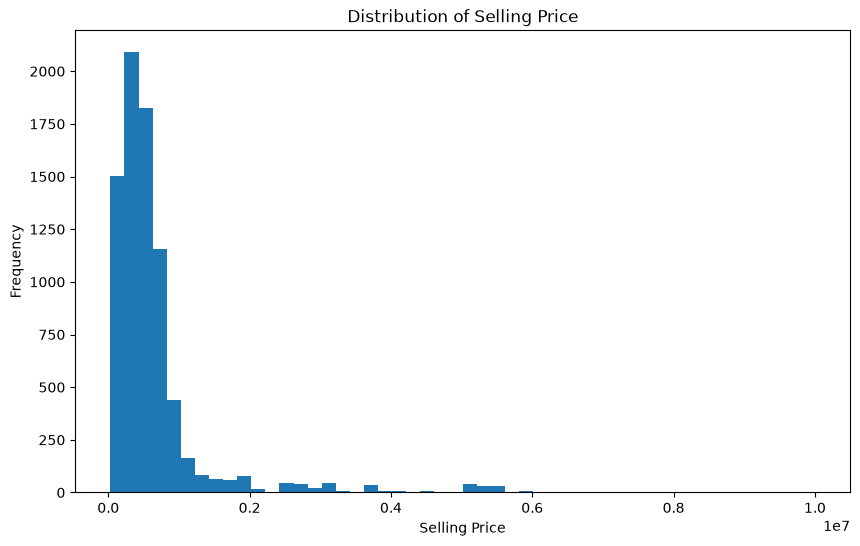

In [45]:
plt.hist(df['selling_price'], bins=50)
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Price')
plt.show();

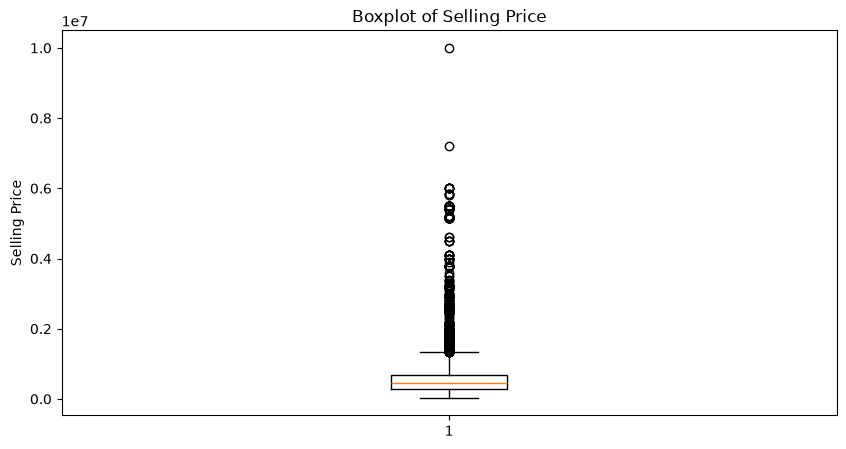

In [46]:
plt.figure(figsize=(10, 5))

plt.boxplot(df['selling_price'])

plt.ylabel('Selling Price')
plt.title('Boxplot of Selling Price')

plt.show()

In [47]:
# we can see from both visuals above that our target variable is right skewed!! and shows the presence of outliers !!!
# And Since selling price or the target variable has a big number or unit, it can cause your prediction to be very unstable. One trick
# is to first transform the label using log transform, i.e., like:
# y = np.log(df['selling_price']), it has a huge positive affect!! which is:
# making the distribution more balanced as seen in the graph below::

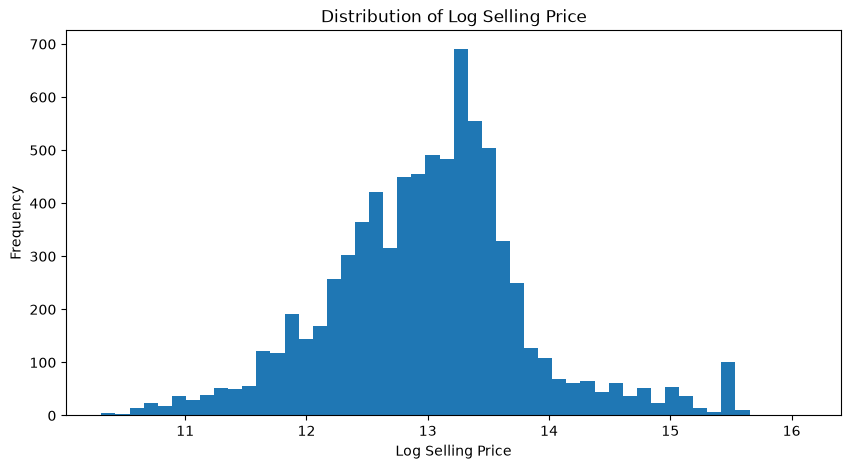

In [48]:
plt.figure(figsize=(10, 5))
plt.hist(np.log(df['selling_price']), bins=50)
plt.xlabel('Log Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Log Selling Price')
plt.show()

In [49]:
# if we are converting our target variable with this technique, we make sure during inference/testing, we have to transform our 
# predicted y back before comparing with y like:
# pred_y = np.exp(pred_y)

### analyzing and understanding numerical features:

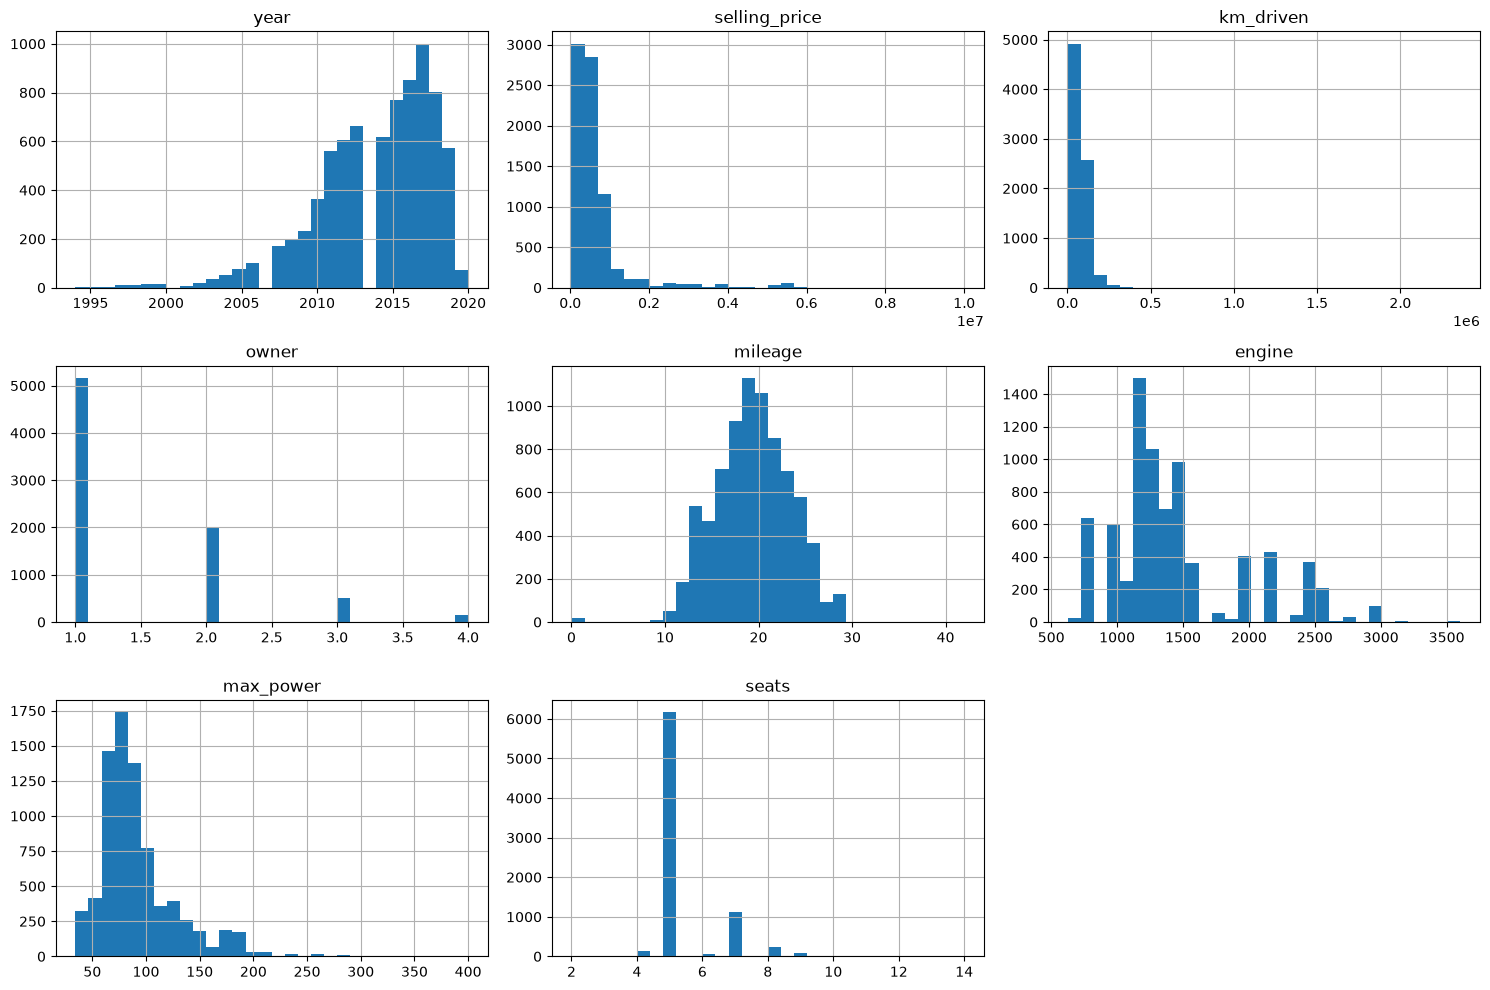

In [50]:
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()
# this histogram graph quickly identifies important things like skewness, outliers, unusual distribution and features with
# limited values

### Relationship between year and selling price:

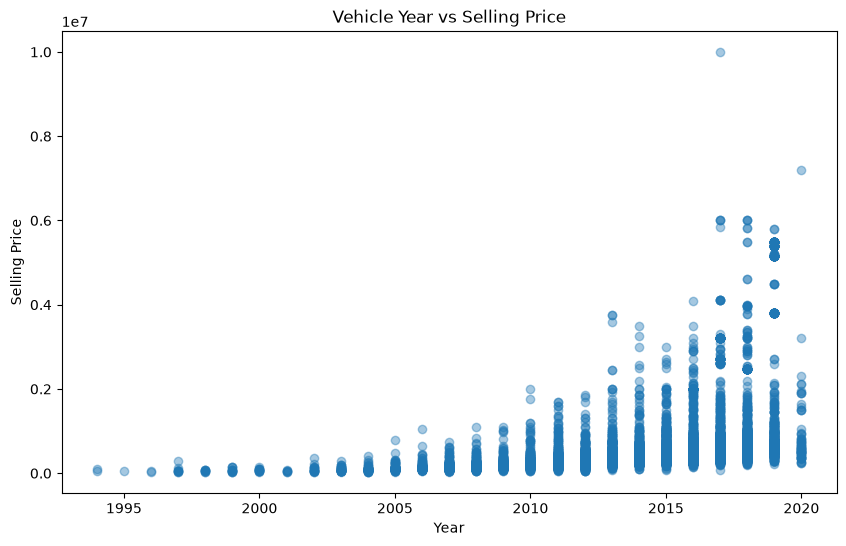

In [51]:
plt.scatter(df['year'], df['selling_price'], alpha=0.4)
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Vehicle Year vs Selling Price')
plt.show()

### relationship between km driven and selling price

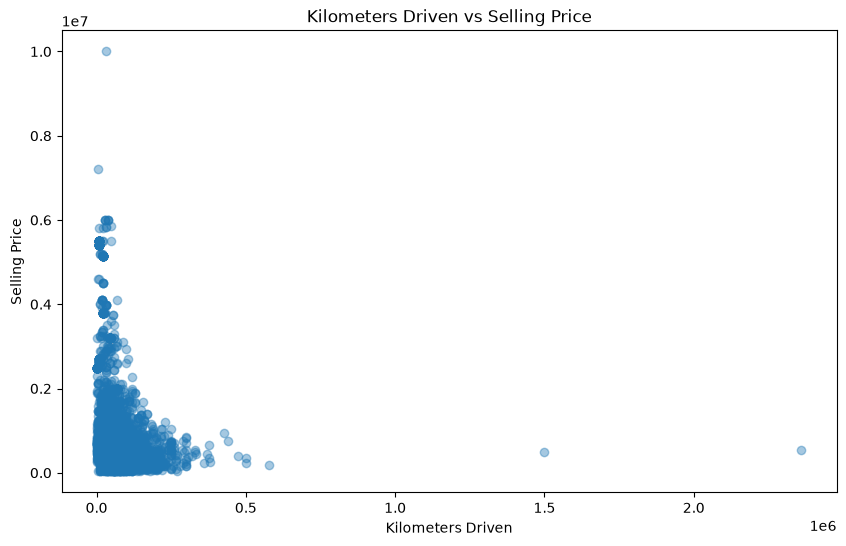

In [52]:
plt.scatter(df['km_driven'], df['selling_price'], alpha=0.4)
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.title('Kilometers Driven vs Selling Price')
plt.show()

### fuel type

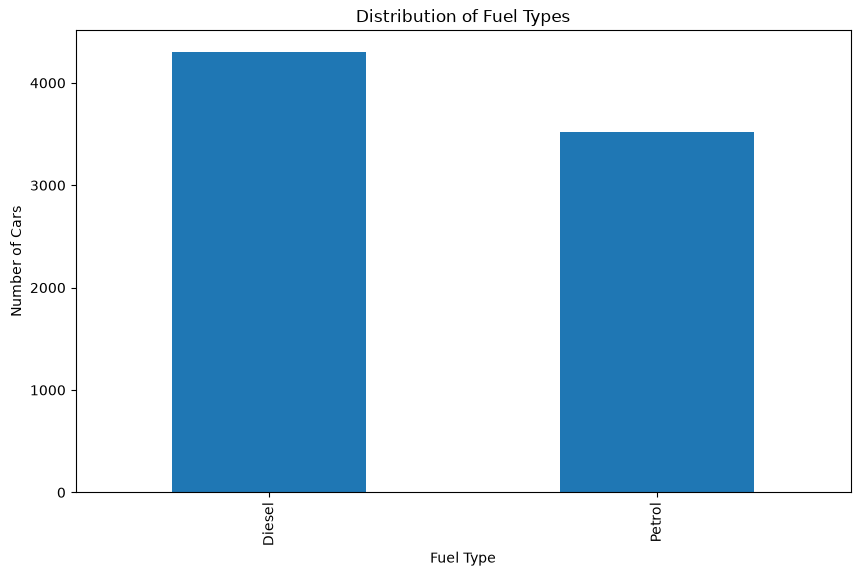

In [53]:
df['fuel'].value_counts().plot(kind='bar')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.title('Distribution of Fuel Types')
plt.show()

In [54]:
df.groupby('fuel')['selling_price'].mean().sort_values()

fuel
Petrol    467324.378555
Diesel    802322.886226
Name: selling_price, dtype: float64

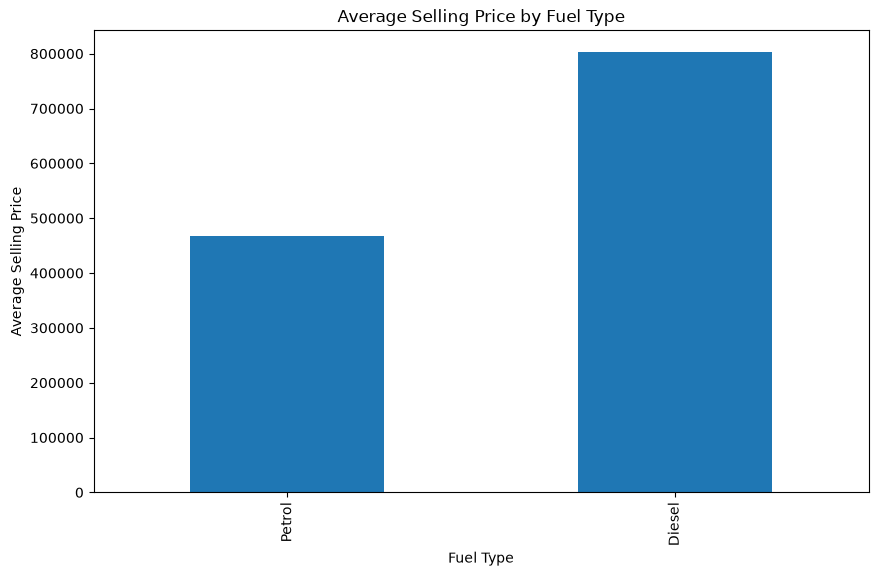

In [55]:
df.groupby('fuel')['selling_price'].mean().sort_values().plot(kind='bar')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Fuel Type')
plt.show()

### transmission analysis

In [56]:
df['transmission'].value_counts()

transmission
Manual       6777
Automatic    1037
Name: count, dtype: int64

In [57]:
df.groupby('transmission')['selling_price'].mean()

transmission
Automatic    1.870304e+06
Manual       4.651013e+05
Name: selling_price, dtype: float64

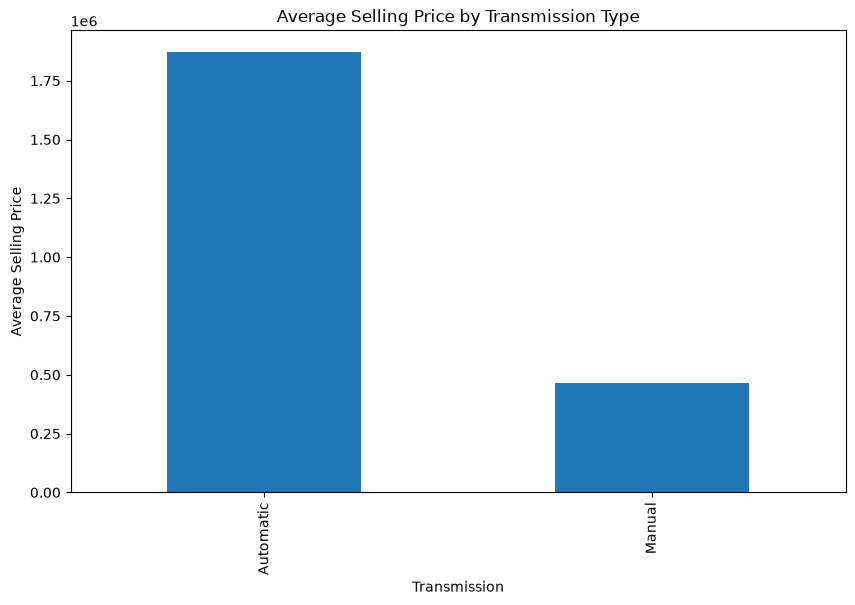

In [58]:
df.groupby('transmission')['selling_price'].mean().plot(kind='bar')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Transmission Type')
plt.show()

### brand analysis

In [59]:
df['brand'].value_counts()

brand
Maruti           2301
Hyundai          1342
Mahindra          758
Tata              718
Honda             465
Toyota            452
Ford              388
Renault           228
Chevrolet         228
Volkswagen        184
BMW               118
Skoda             104
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               41
Audi               37
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Kia                 4
Ambassador          4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Name: count, dtype: int64

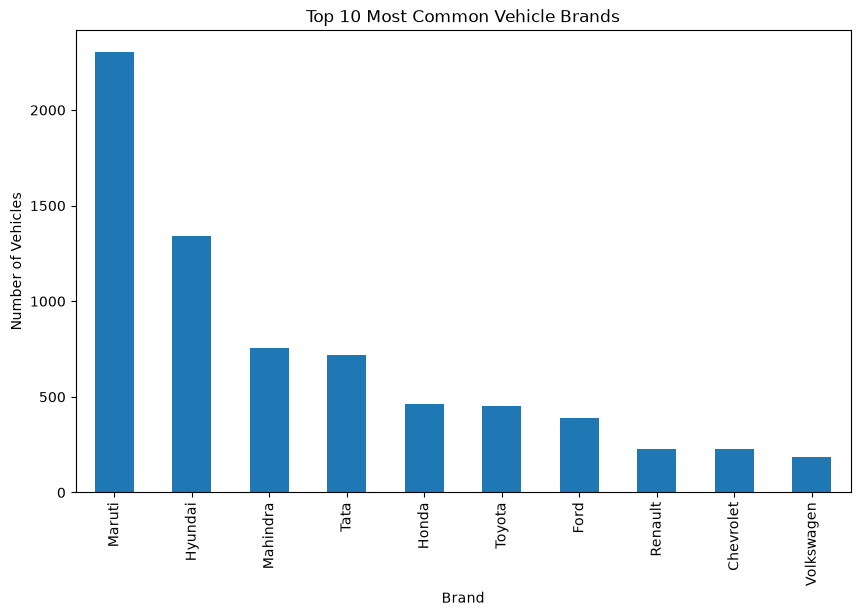

In [60]:
df['brand'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Brand')
plt.ylabel('Number of Vehicles')
plt.title('Top 10 Most Common Vehicle Brands')
plt.show()

In [61]:
df.groupby('brand')['selling_price'].mean().sort_values(ascending=False)

brand
Lexus            5.150000e+06
BMW              4.153814e+06
Land             3.608333e+06
Volvo            3.272015e+06
Jaguar           2.915465e+06
Mercedes-Benz    2.470444e+06
Audi             2.319432e+06
Jeep             2.149613e+06
Isuzu            1.942000e+06
MG               1.783333e+06
Kia              1.504500e+06
Toyota           1.011920e+06
Force            8.875000e+05
Mitsubishi       8.175000e+05
Mahindra         6.300211e+05
Skoda            6.097211e+05
Honda            5.939035e+05
Ford             5.208737e+05
Volkswagen       4.852174e+05
Hyundai          4.765339e+05
Nissan           4.654074e+05
Renault          4.626184e+05
Maruti           4.123969e+05
Tata             3.621419e+05
Fiat             3.171951e+05
Datsun           3.146000e+05
Ashok            3.000000e+05
Chevrolet        2.745154e+05
Ambassador       1.240000e+05
Daewoo           7.700000e+04
Opel             6.800000e+04
Name: selling_price, dtype: float64

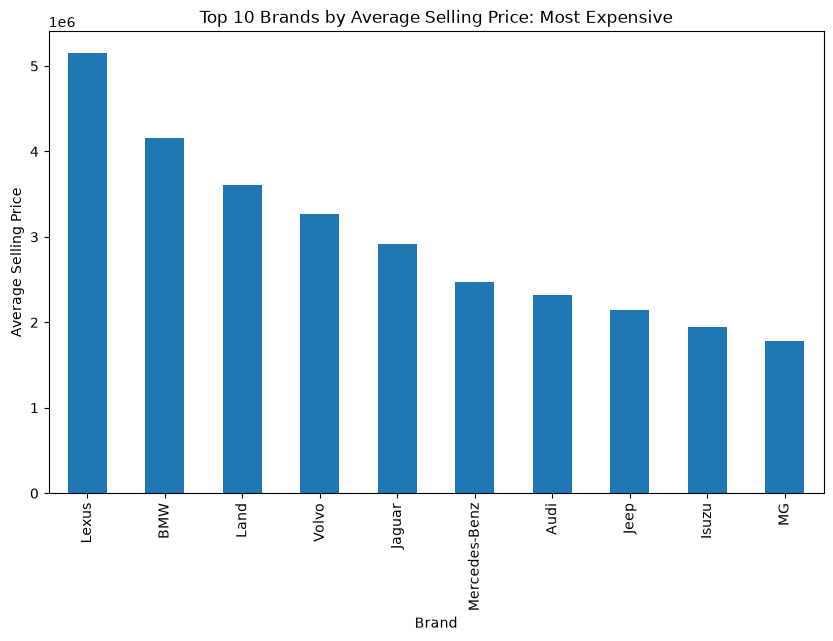

In [62]:
df.groupby('brand')['selling_price'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind='bar')

plt.xlabel('Brand')
plt.ylabel('Average Selling Price')
plt.title('Top 10 Brands by Average Selling Price: Most Expensive')
plt.show()

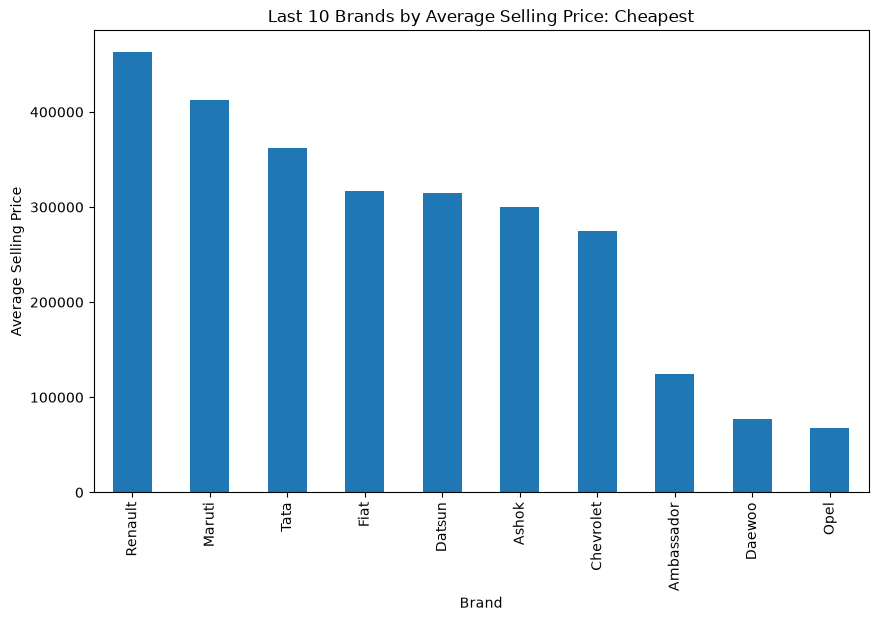

In [63]:
df.groupby('brand')['selling_price'] \
    .mean() \
    .sort_values(ascending=False) \
    .tail(10) \
    .plot(kind='bar')

plt.xlabel('Brand')
plt.ylabel('Average Selling Price')
plt.title('Last 10 Brands by Average Selling Price: Cheapest')
plt.show()

### Seller Type Analysis

In [64]:
df['seller_type'].value_counts()

seller_type
Individual          6477
Dealer              1101
Trustmark Dealer     236
Name: count, dtype: int64

In [65]:
df.groupby('seller_type')['selling_price'].mean().sort_values()

seller_type
Individual          5.107899e+05
Trustmark Dealer    8.018390e+05
Dealer              1.447662e+06
Name: selling_price, dtype: float64

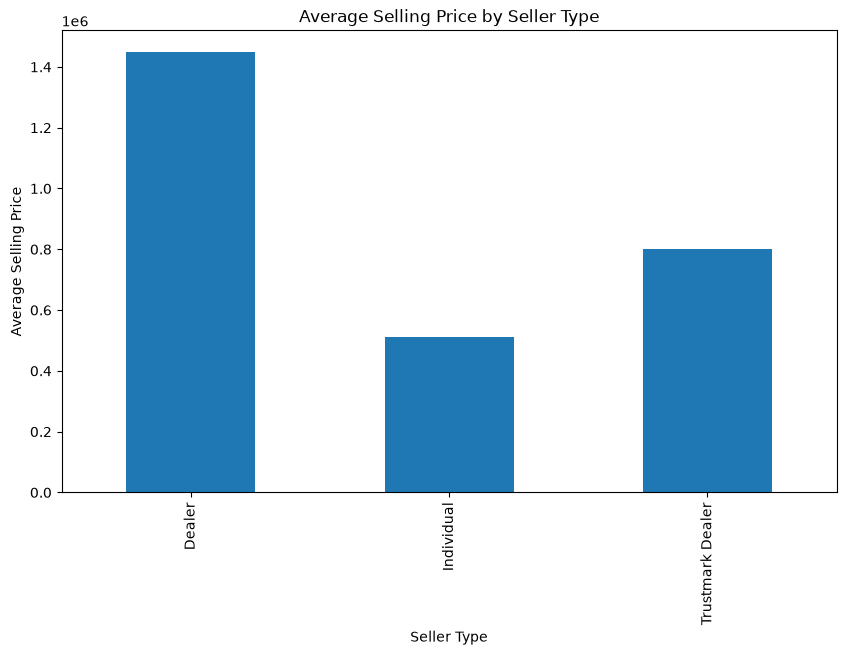

In [66]:
df.groupby('seller_type')['selling_price'].mean().plot(kind='bar')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Seller Type')
plt.show()

### owner vs selling price

In [67]:
df.groupby('owner')['selling_price'].mean()

owner
1    794495.653630
2    403772.245473
3    294879.747515
4    233560.075949
Name: selling_price, dtype: float64

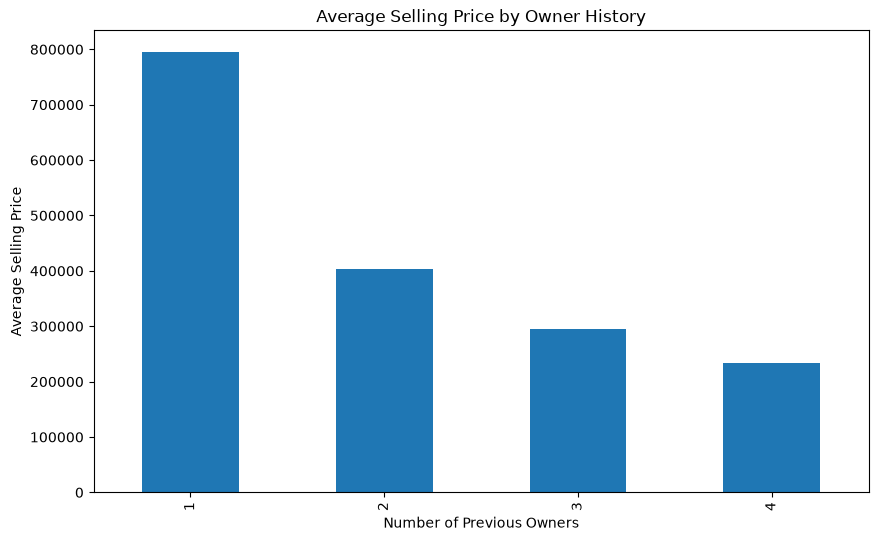

In [68]:
df.groupby('owner')['selling_price'].mean().plot(kind='bar')
plt.xlabel('Number of Previous Owners')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Owner History')
plt.show()

### mileage vs selling price

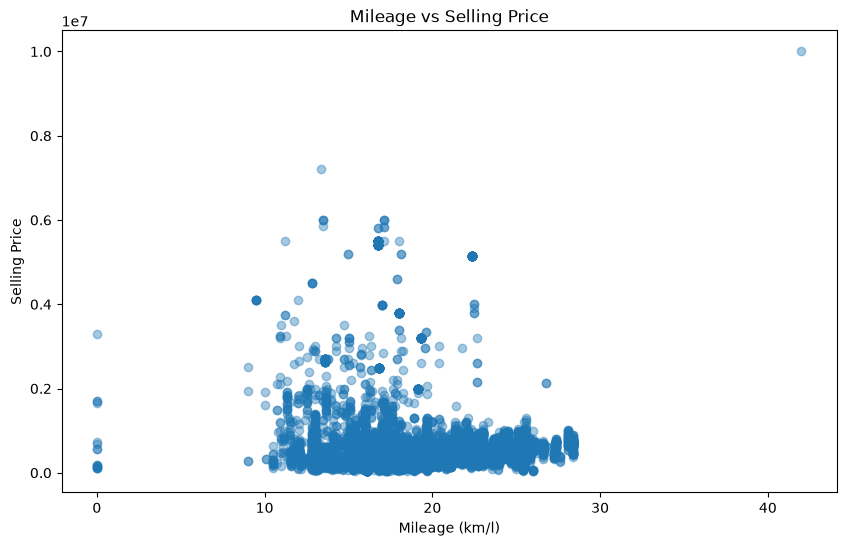

In [69]:
plt.figure(figsize=(10, 6))
plt.scatter(df['mileage'], df['selling_price'], alpha=0.4)
plt.xlabel('Mileage (km/l)')
plt.ylabel('Selling Price')
plt.title('Mileage vs Selling Price')
plt.show()

### engine size vs selling price

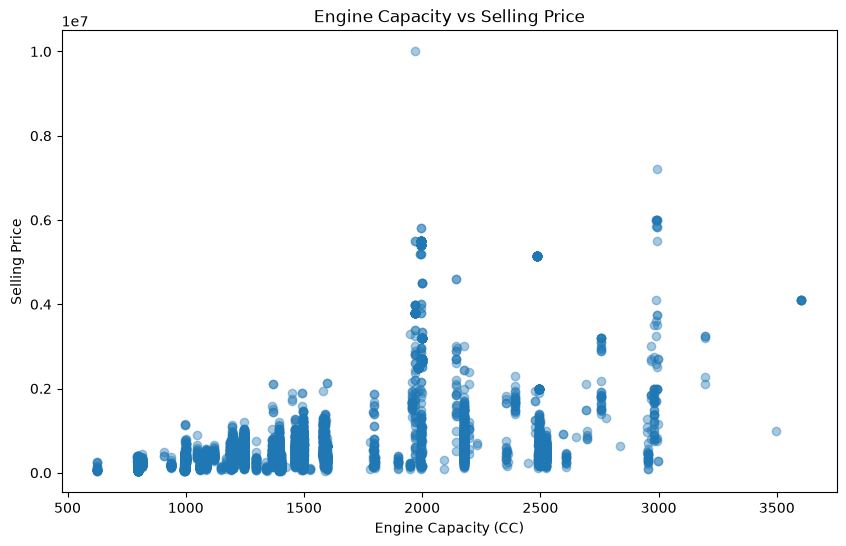

In [70]:
plt.figure(figsize=(10, 6))
plt.scatter(df['engine'], df['selling_price'], alpha=0.4)
plt.xlabel('Engine Capacity (CC)')
plt.ylabel('Selling Price')
plt.title('Engine Capacity vs Selling Price')
plt.show()

### max power vs selling price

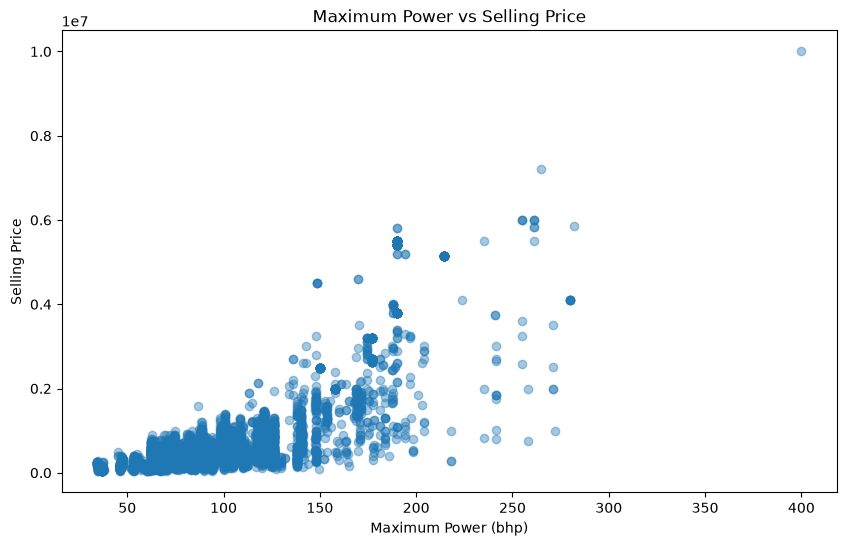

In [71]:
plt.figure(figsize=(10, 6))
plt.scatter(df['max_power'], df['selling_price'], alpha=0.4)
plt.xlabel('Maximum Power (bhp)')
plt.ylabel('Selling Price')
plt.title('Maximum Power vs Selling Price')
plt.show()

### number of seats vs selling price

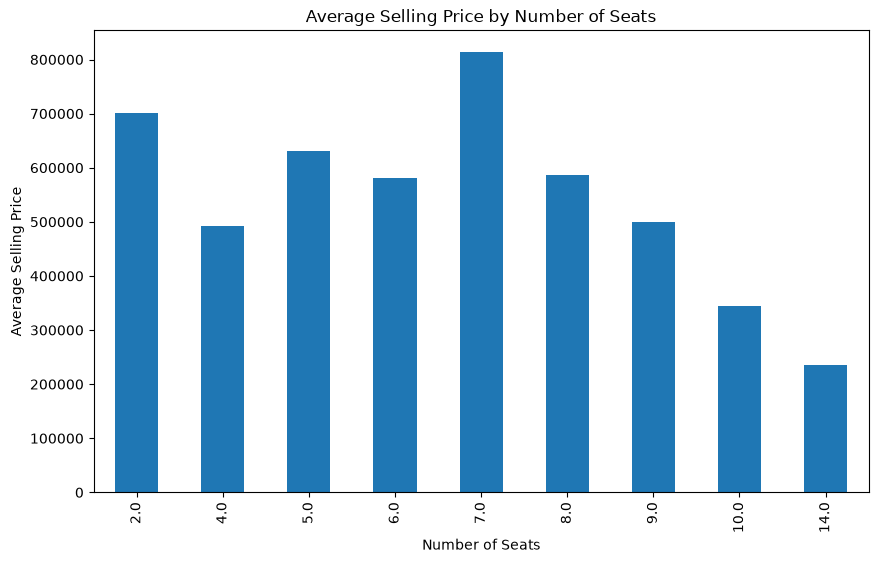

In [72]:
df.groupby('seats')['selling_price'].mean().plot(kind='bar')
plt.xlabel('Number of Seats')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Number of Seats')
plt.show()

### Feature Engineering

In [73]:
df['car_age'] = 2026 - df['year']
df.head()
# we are adding the car age column, but can cause the problem of high variance or multicollinearity, as it essentially gives the same 
# information as year column or feature!!

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,12
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,12
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,20
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,16
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,19


### correlation analysis

In [74]:
df.select_dtypes(include='number').corr()

,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,car_age
year,1.000000,0.413231,-0.427758,-0.508635,0.328817,0.016725,0.226628,-0.007718,-1.000000
selling_price,0.413231,1.000000,-0.221638,-0.235333,-0.124062,0.456359,0.750428,0.041003,-0.413231
km_driven,-0.427758,-0.221638,1.000000,0.289218,-0.173733,0.209019,-0.036315,0.228646,0.427758
owner,-0.508635,-0.235333,0.289218,1.000000,-0.174818,0.007559,-0.111767,0.030173,0.508635
mileage,0.328817,-0.124062,-0.173733,-0.174818,1.000000,-0.578707,-0.372881,-0.454411,-0.328817
engine,0.016725,0.456359,0.209019,0.007559,-0.578707,1.000000,0.701834,0.610481,-0.016725
max_power,0.226628,0.750428,-0.036315,-0.111767,-0.372881,0.701834,1.000000,0.189248,-0.226628
seats,-0.007718,0.041003,0.228646,0.030173,-0.454411,0.610481,0.189248,1.000000,0.007718
car_age,-1.000000,-0.413231,0.427758,0.508635,-0.328817,-0.016725,-0.226628,0.007718,1.000000


**as the year and car age columns has essentially same information they will have strong negative correlation!!**

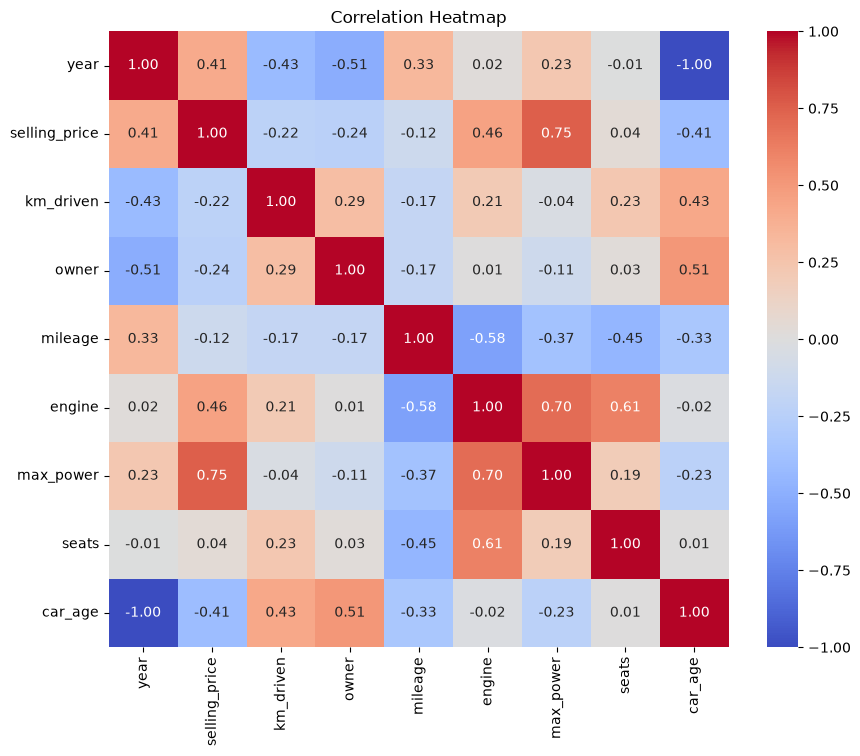

In [75]:
correlation = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

**as the year and car age columns has essentially same information they will have strong negative correlation!! so address the problem of high variance or multicollinearity for gradient descent based models like linear regression before going to modelling**

In [76]:
df.select_dtypes(include='number') \
    .corr()['selling_price'] \
    .sort_values(ascending=False)

selling_price    1.000000
max_power        0.750428
engine           0.456359
year             0.413231
seats            0.041003
mileage         -0.124062
km_driven       -0.221638
owner           -0.235333
car_age         -0.413231
Name: selling_price, dtype: float64

### Pairplot analysis

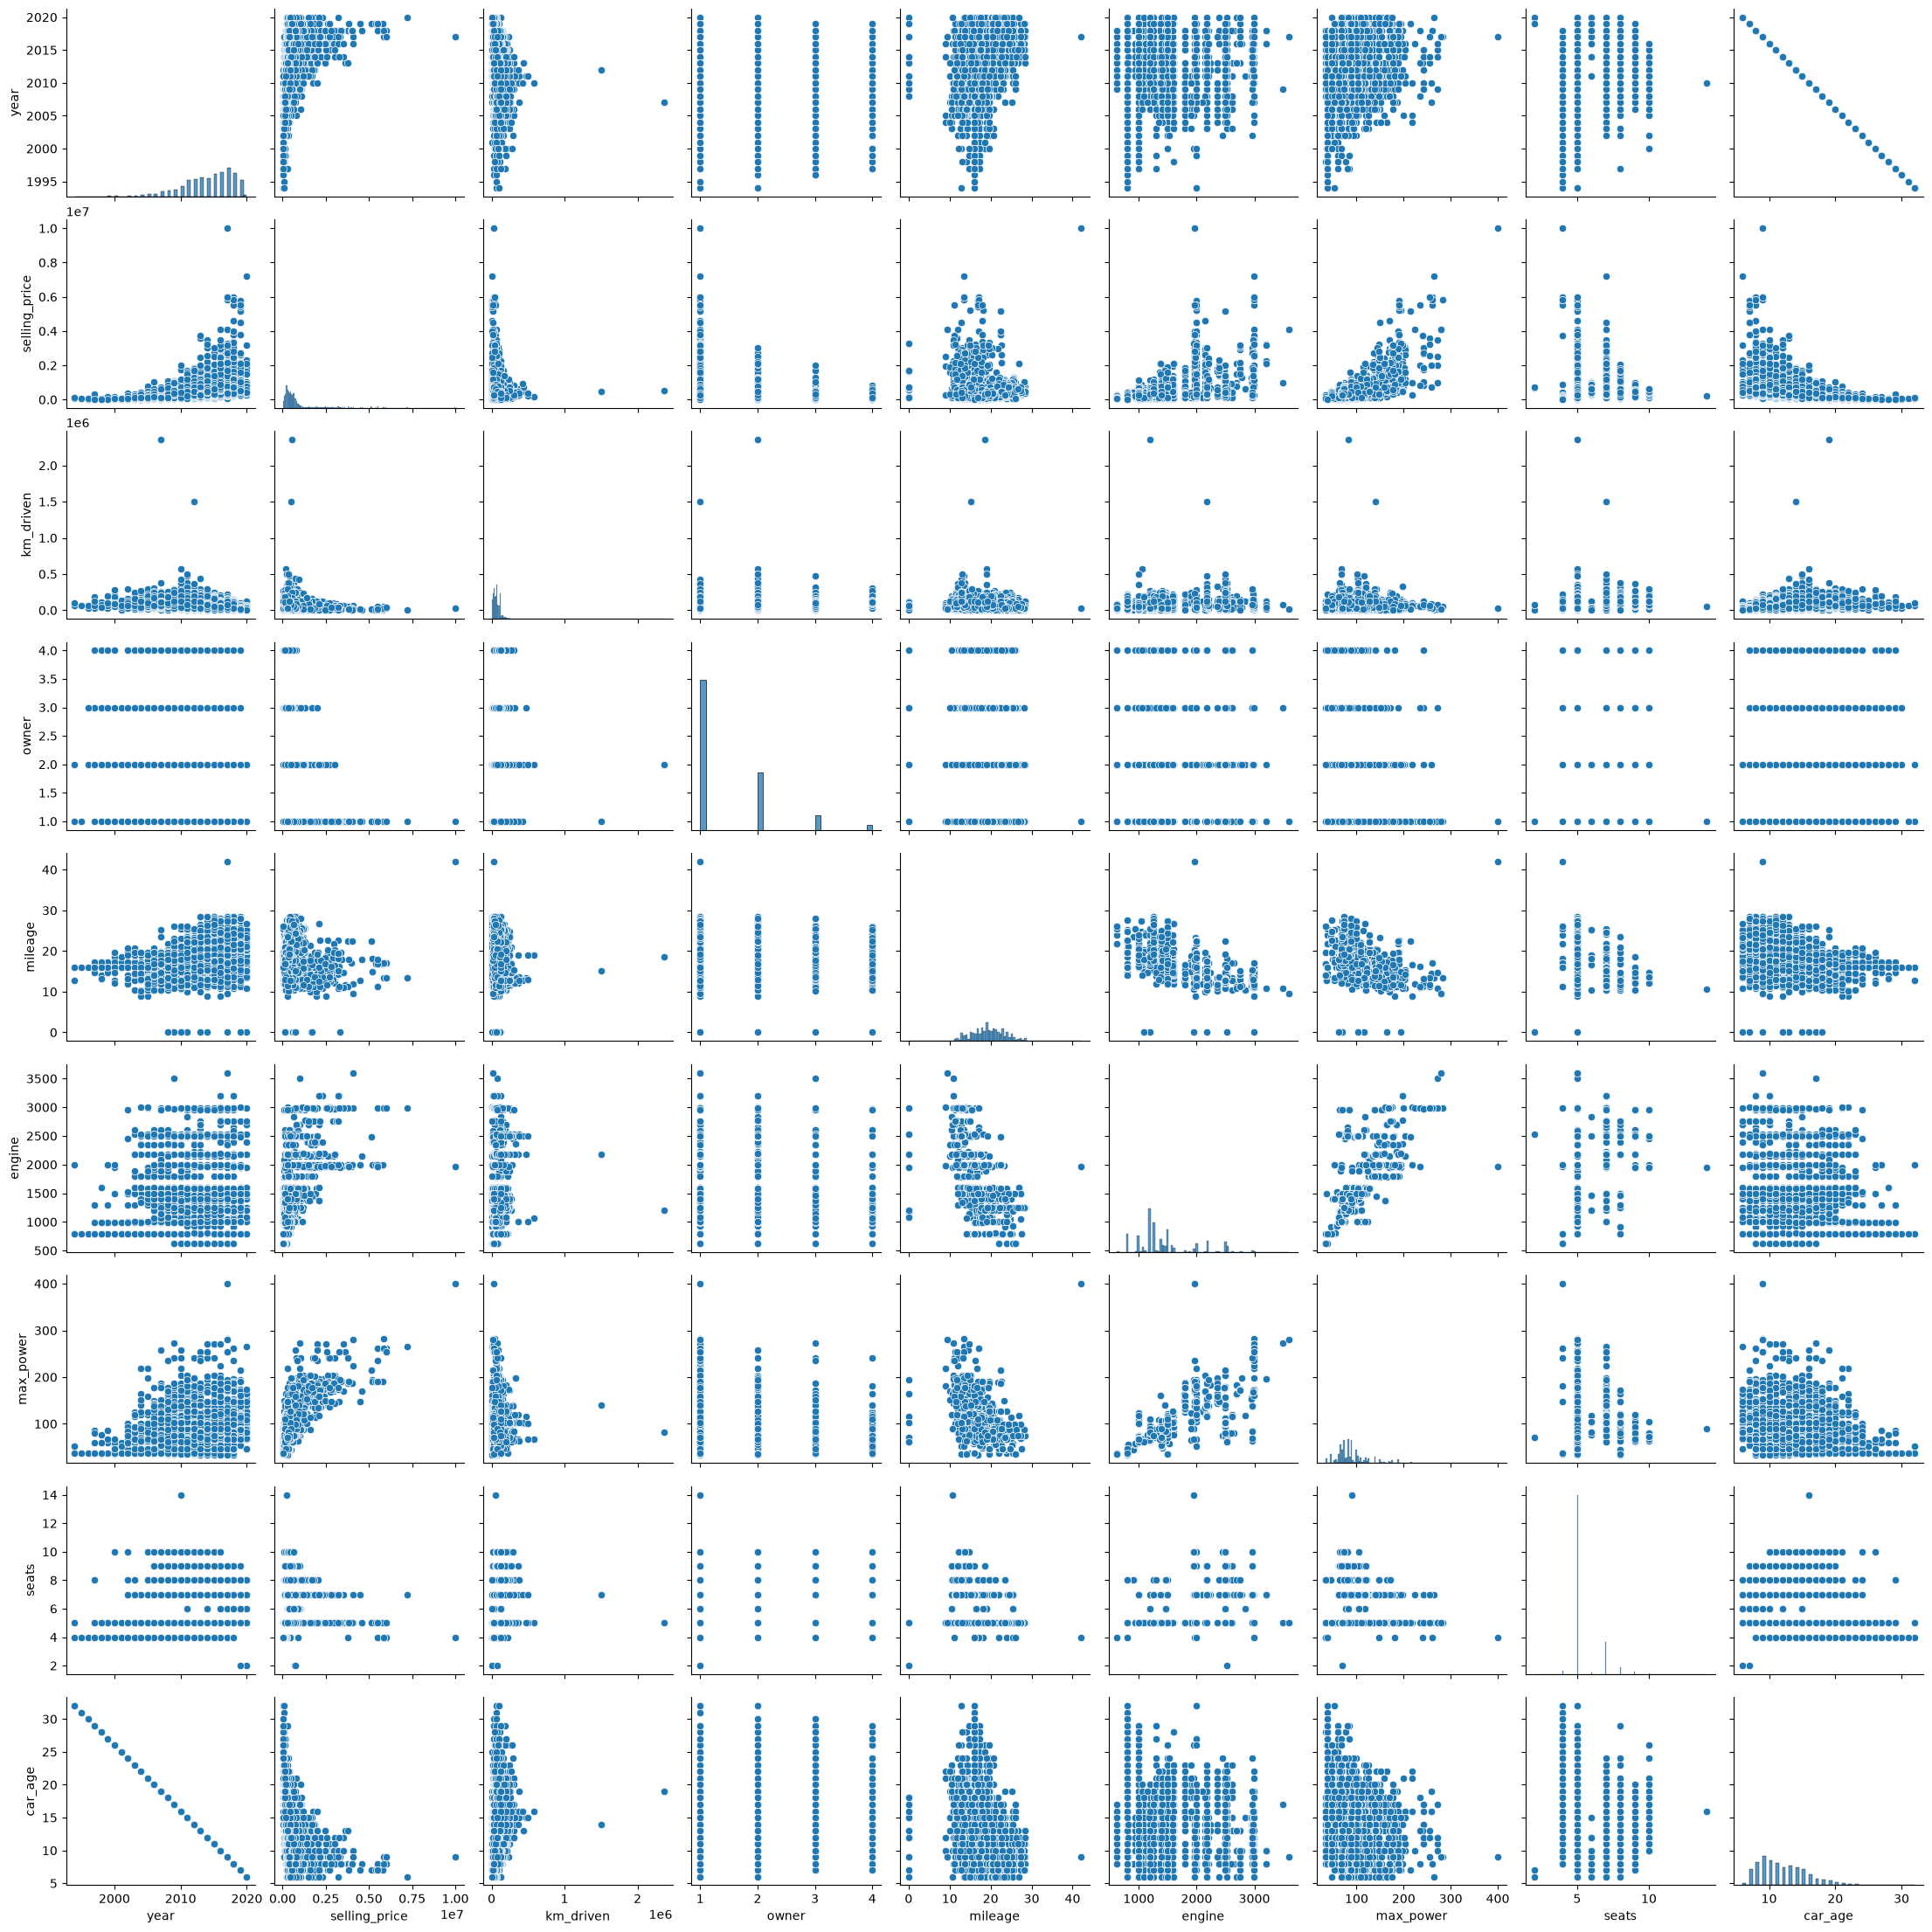

In [77]:
sns.pairplot(df);

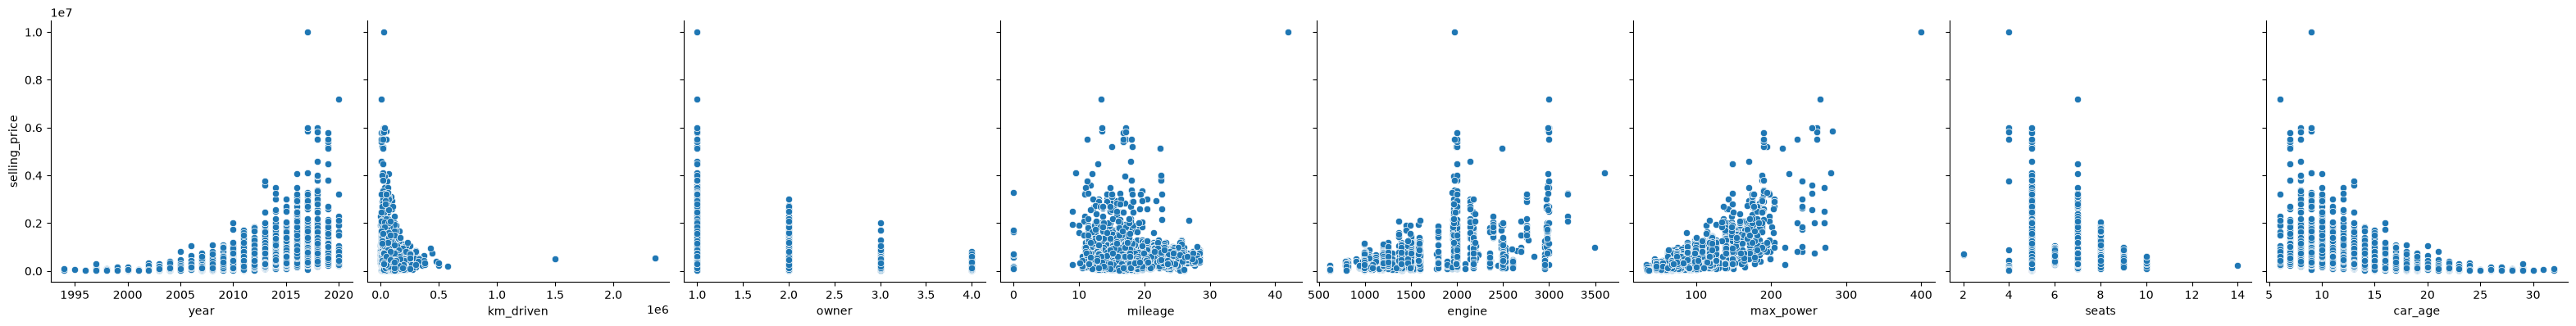

In [78]:
numerical_features = df.select_dtypes(include='number').columns.drop('selling_price')

sns.pairplot(
    df,
    x_vars=numerical_features,
    y_vars=['selling_price'],
    height=4
)

plt.show()

**the pairplot lf year and age with respect to target variable is exact opposit of each other, showing the have exact opposit information of each other!!**

**another important thing we can notice here is that very few of these features have linear relationship with the target variable, it may indicate the presence of other types of relationship with target variable than linear, so a polynomial model may give a better result than linear regression, as it may describte the nature of relationship better**

**other models can also be tried!!!**

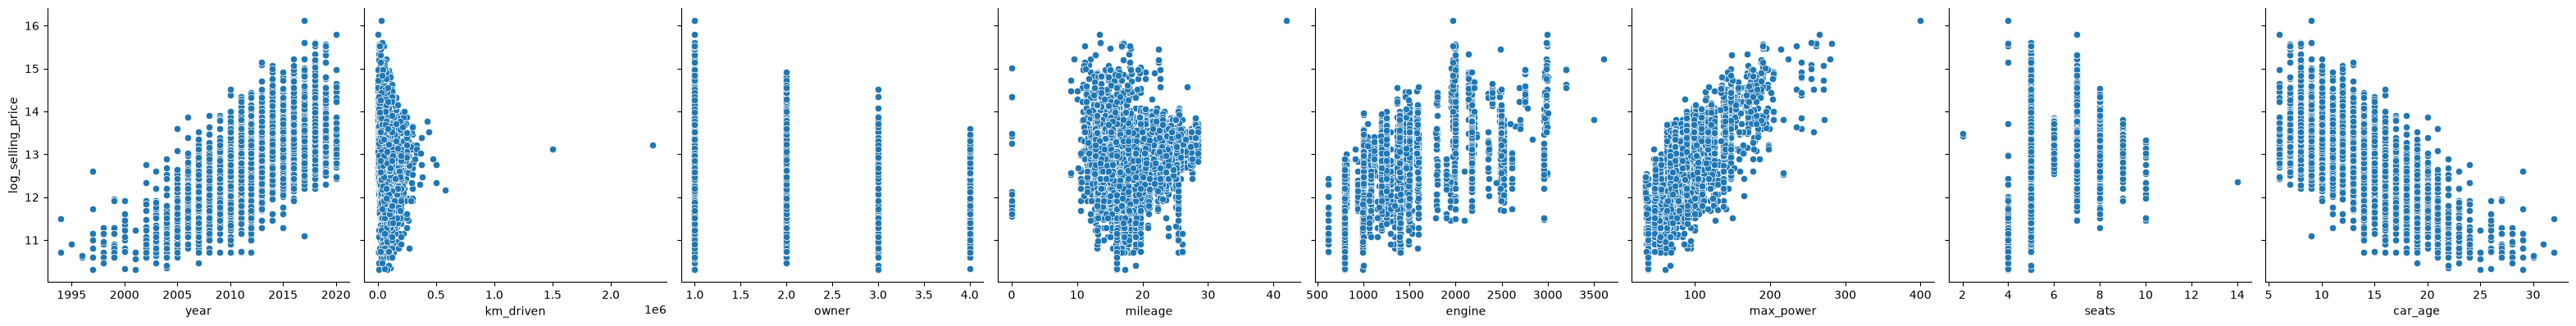

In [79]:
df['log_selling_price'] = np.log(df['selling_price'])
numerical_features = (
    df.select_dtypes(include='number')
    .columns
    .drop(['selling_price', 'log_selling_price'])
)

sns.pairplot(
    df,
    x_vars=numerical_features,
    y_vars=['log_selling_price'],
    height=4
)

plt.show()

**Note:** The logarithmic transformation clearly reduced the effect of extremely high selling prices and compressed the range of the target variable. As a result, the distribution of `selling_price` became less right-skewed, and the relationships between the target variable and the numerical features became clearer and easier to observe in the pairplot. The transformation reduced the visual dominance of extreme price values and revealed patterns that were less apparent when using the original selling prices.


In [80]:
# performing the logarithmic transformation added a new column, make sure to delete it!!
df.head(2)

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age,log_selling_price
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,12,13.017003
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,12,12.821258


In [81]:
df = df.drop(columns=['log_selling_price'])
df.head(2)

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,12
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,12


## The problem of multicollinearity!!

- The multicollinearity issue arises as a problem in gradient descent-based models like linear and logistic regression.

- Multicollinearity occurs when there is a high correlation between independent variables. This situation can reduce the importance of other independent variables in the model when one independent variable is strongly related to others.

- The multicollinearity problem can make it difficult to correctly interpret the model. It is challenging to accurately estimate model coefficients, which can lead to the incorrect interpretation of the effects of certain variables. Therefore, to obtain correct results, the multicollinearity problem should be eliminated.

- Regularization algorithms not only address the overfitting problem but also resolve the multicollinearity issue.

Multicollinearity describes a situation where there is a high degree of linear relationship between independent variables. While multicollinearity can be problematic for some statistical models, it may not be as critical for others.

In [82]:
df = df.drop(columns=['year'])
df.head()

,brand,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
0,Maruti,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,12
1,Skoda,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,12
2,Honda,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,20
3,Hyundai,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,16
4,Maruti,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,19


**Addressing Multicollinearity**

During the exploratory analysis, it was observed that the newly created `age` feature has a perfect negative correlation of **-1** with the `year` feature. This occurs because `age` was directly calculated from the vehicle's manufacturing year, meaning that the two variables contain essentially the same information.

Keeping both `year` and `age` would therefore introduce perfect multicollinearity into the dataset. This can be particularly problematic for regression-based models, as highly correlated independent variables can make coefficient estimates unstable and make the individual effects of features more difficult to interpret.

To address this issue, the `year` feature will be removed while retaining `age`. Age is kept because it provides a more intuitive representation of how old a vehicle is, which may have a more direct and interpretable relationship with its selling price.

Removing `year` eliminates this redundancy and ensures that the dataset does not contain two features representing the same underlying information.


### Addressing the issue with the brand column

In [83]:
df.brand.value_counts()

brand
Maruti           2301
Hyundai          1342
Mahindra          758
Tata              718
Honda             465
Toyota            452
Ford              388
Renault           228
Chevrolet         228
Volkswagen        184
BMW               118
Skoda             104
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               41
Audi               37
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Kia                 4
Ambassador          4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Name: count, dtype: int64

**Note:** After examining the value counts of the `brand` feature, it was observed that several car brands occur only a very small number of times in the dataset. These rare categories may provide insufficient data for the machine learning model to learn reliable patterns and can unnecessarily increase the complexity of the feature after categorical encoding. In addition, treating each extremely rare brand as a separate category may increase the risk of the model learning patterns that are specific to only a few observations rather than patterns that generalize well to unseen vehicles.

Therefore, the brands with fewer than 10 observations will be grouped into a single `Rare Brands` category. This approach reduces unnecessary categorical complexity while preserving the observations and their remaining useful features.


In [84]:
brand_counts = df['brand'].value_counts()

rare_brands = brand_counts[brand_counts < 10].index

df['brand'] = df['brand'].replace(rare_brands, 'Rare Brands')

df.brand.value_counts()

brand
Maruti           2301
Hyundai          1342
Mahindra          758
Tata              718
Honda             465
Toyota            452
Ford              388
Renault           228
Chevrolet         228
Volkswagen        184
BMW               118
Skoda             104
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               41
Audi               37
Lexus              34
Rare Brands        33
Jeep               31
Mitsubishi         14
Name: count, dtype: int64

In [85]:
df.head()

,brand,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
0,Maruti,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,12
1,Skoda,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,12
2,Honda,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,20
3,Hyundai,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,16
4,Maruti,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,19


In [86]:
## Now we are done with understanding, and analyzing the data, we can go to splitting the data and training the model!! our data is ready!!

## Train | Test Split

In [87]:
X = df.drop(columns=['selling_price'])
y = np.log(df['selling_price'])

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Now that we are done with the split, we need to deal with our columns appropriately!!**
- columns like, owner seats and car age are categoric and numeric, so ready for ml, and no need to scale it as it is also contains categorical information!!
- columns like brand, fuel, seller type and transmission have categorical and str data, so we need to perform encoding
- and columns like km driven, mileage, engine and max power has continuous values, so scaling must be performed on them!

In [89]:
numerical_features = [
    'km_driven',
    'mileage',
    'engine',
    'max_power'
]

categorical_features = [
    'brand',
    'fuel',
    'seller_type',
    'transmission'
]

remaining_features = [
    'car_age',
    'seats',
    'owner'
]

In [90]:
# defining the preprocessor that combines  all of these mentioned steps
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

**Now our data is ready for any machine learning model. while training any model, we will combine the preprocessor with the model in a pipeline**

# ML Implementation

## Linear Regression

### Vanilla or Base Model Fit

In [91]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)
model.fit(X_train, y_train) # training on the data

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['brand','km_driven','fuel',...,'max_power','seats','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concat

### Vanilla or Base Model Evaluation

In [92]:
# since our target variable was converted using 
# y = np.log(df['selling_price']), 
# we must remember to convert it back!!


In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_val(model, X_train, y_train, X_test, y_test):
    
    # Predictions on the log scale
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    
    # Convert predictions back to the original selling price scale
    y_pred = np.exp(y_pred)
    y_train_pred = np.exp(y_train_pred)
    
    # Convert actual values back to the original selling price scale
    y_test_original = np.exp(y_test)
    y_train_original = np.exp(y_train)
    
    scores = {
        "train": {
            "R2": r2_score(y_train_original, y_train_pred),
            "mae": mean_absolute_error(y_train_original, y_train_pred),
            "mse": mean_squared_error(y_train_original, y_train_pred),
            "rmse": np.sqrt(
                mean_squared_error(y_train_original, y_train_pred)
            )
        },
        
        "test": {
            "R2": r2_score(y_test_original, y_pred),
            "mae": mean_absolute_error(y_test_original, y_pred),
            "mse": mean_squared_error(y_test_original, y_pred),
            "rmse": np.sqrt(
                mean_squared_error(y_test_original, y_pred)
            )
        }
    }
    
    return pd.DataFrame(scores).round(2)

In [94]:
train_val(model, X_train, y_train, X_test, y_test)

,train,test
R2,9.200000e-01,9.100000e-01
mae,1.087627e+05,1.139520e+05
mse,4.990164e+10,5.794905e+10
rmse,2.233867e+05,2.407261e+05


**Let's interpret the scores**
- after comparing the train and test scores we can safely say that there is no much difference between train and test score, so there may not be overfitting.
- r2 scores are around 0.92 and 0.91 which is very high, so our columns can describe 91% of the variance or information of the target variable.
- mae is around 108762.7 and 113952.0 which means, while making prediction of the prices of the cars, our model may be off around these amounts
- rmse is around 223386.7 and 240726.1 which means, while making prediction of the prices of the cars, our model may be off around these amounts
- since rmse is higher than mae, it means that from time to time our model make big errors, that's why rmse penalizes these errors!!


**To make sure we have no overfitting in our model, we must try cross validation**

In [95]:
# store it to make model comparison at the end
# Make predictions
y_pred = model.predict(X_test)

# Evaluation
linear_R2 = r2_score(y_test, y_pred)
linear_mae = mean_absolute_error(y_test, y_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

### Cross Validation

**To get the results of cross validation in terms of real y instead of logarithmic one:**

In [96]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

def r2_original(model, X, y):
    y_pred = np.exp(model.predict(X))
    y_true = np.exp(y)

    return r2_score(y_true, y_pred)


def mae_original(model, X, y):
    y_pred = np.exp(model.predict(X))
    y_true = np.exp(y)

    return -mean_absolute_error(y_true, y_pred)


def mse_original(model, X, y):
    y_pred = np.exp(model.predict(X))
    y_true = np.exp(y)

    return -mean_squared_error(y_true, y_pred)


def rmse_original(model, X, y):
    y_pred = np.exp(model.predict(X))
    y_true = np.exp(y)

    return -np.sqrt(mean_squared_error(y_true, y_pred))

In [97]:
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# define the model:
# Create the pipeline
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# perform cross validation
scores = cross_validate(
    model,
    X_train,
    y_train,
    scoring={
        'r2': r2_original,
        'mae': mae_original,
        'mse': mse_original,
        'rmse': rmse_original
    },
    cv=cv,
    return_train_score=True
)

In [98]:
cv_results = pd.DataFrame({
    'train': [
        scores['train_r2'].mean(),
        -scores['train_mae'].mean(),
        -scores['train_mse'].mean(),
        -scores['train_rmse'].mean()
    ],

    'validation': [
        scores['test_r2'].mean(),
        -scores['test_mae'].mean(),
        -scores['test_mse'].mean(),
        -scores['test_rmse'].mean()
    ]
},
index=['R2', 'MAE', 'MSE', 'RMSE']
)

cv_results.round(2)

,train,validation
R2,9.200000e-01,9.200000e-01
MAE,1.087161e+05,1.096821e+05
MSE,4.982750e+10,5.171901e+10
RMSE,2.231987e+05,2.257511e+05


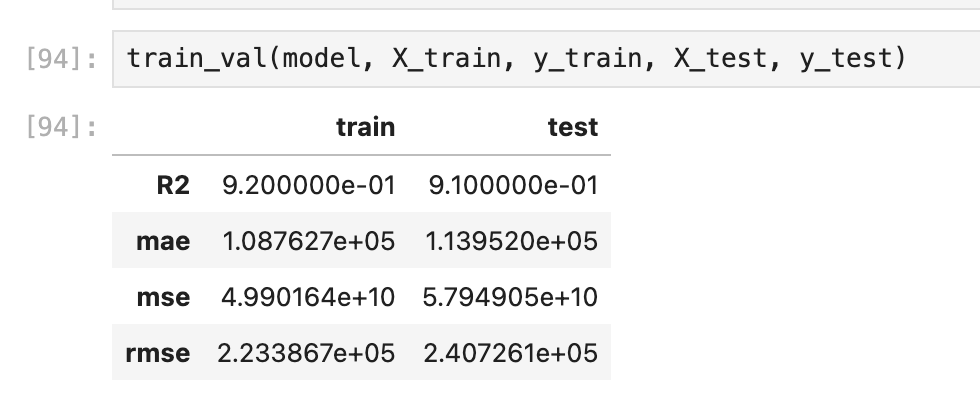

**Note:** After performing 10-fold cross-validation, the training and validation scores are very close across all metrics. Both R² scores are approximately **0.92**, while the error metrics show only small differences. This indicates that the model generalizes consistently across different subsets of the data and shows no significant indication of overfitting.


**Now that we are sure there is no overfitting, let's find the relatinve error:**
rmse = 240726.1

In [99]:
df.selling_price.mean()

np.float64(651586.4192475044)

In [100]:
240726.1 / df.selling_price.mean()
# although the model seems like a good one, but the relative error is very high!!

np.float64(0.369446159233961)

**Now let's try it with mae:**
mae = 113952

In [101]:
113952 / df.selling_price.mean()

np.float64(0.17488393961863016)

In [102]:
# the reasons for this huge difference between mae and rmse is due to some really high values cars, or maybe even outliers!!
# that's why rmse penalizes the the error!!

### Prediction Error

- Identity line → perfect predictions (Predicted = Actual)
- Best-fit/regression line → shows the overall relationship between actual and predicted values

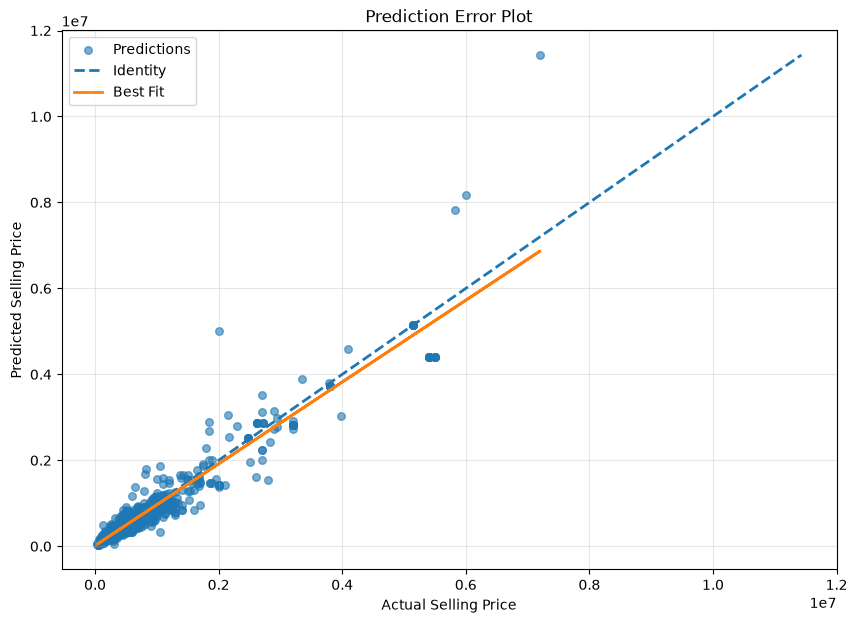

In [103]:
# Declare the model
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Fit the model
model.fit(X_train, y_train)

# Make predictions (log scale)
y_pred_log = model.predict(X_test)

# Convert predictions and actual values back to original scale
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)


# Create the plot
plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(
    y_test_real,
    y_pred,
    alpha=0.6,
    s=30,
    label='Predictions'
)


# -------------------------
# Identity / Perfect Prediction Line
# -------------------------

min_value = min(y_test_real.min(), y_pred.min())
max_value = max(y_test_real.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    '--',
    linewidth=2,
    label='Identity'
)


# -------------------------
# Best-Fit Line
# -------------------------

slope, intercept = np.polyfit(y_test_real, y_pred, 1)

best_fit = slope * y_test_real + intercept

plt.plot(
    y_test_real,
    best_fit,
    linewidth=2,
    label='Best Fit'
)


plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Prediction Error Plot')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

we can see that our model is affected by the outliers in our dataset, although the number might be less or few, but it definitely diverged our model from the perfect prediction
- Identity line → perfect predictions (Predicted = Actual)
- Best-fit/regression line → shows the overall relationship between actual and predicted values

### Residual Plot

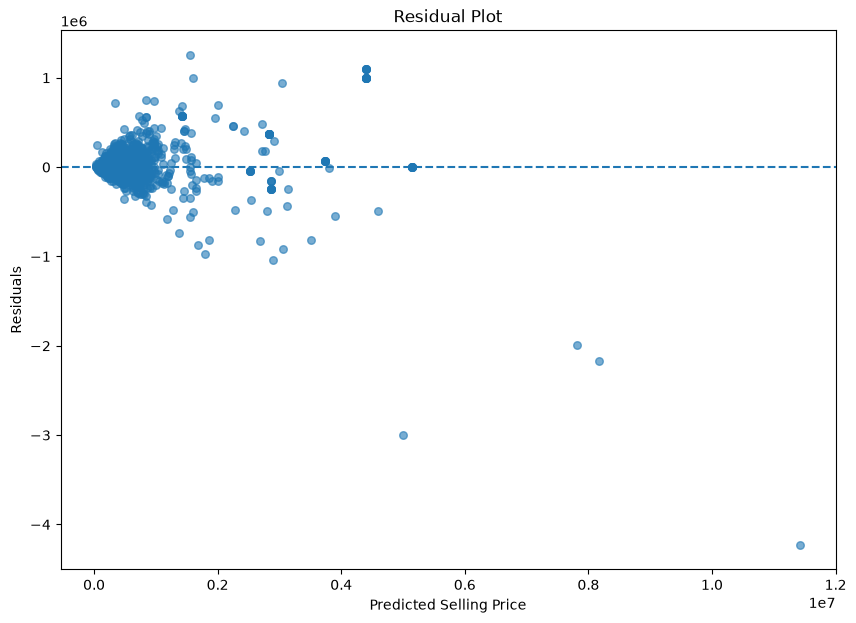

In [104]:
residuals = y_test_real - y_pred

plt.figure(figsize=(10, 7))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6,
    s=30
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

We can see that there are really big residuals that affec rmse alot, these are the big errors of our model for which rmse penalized. and we can see that they are all around and after 0.5 predicted selling price. if we exclude the cars or vehicles whose price coincide here, we will get the best model we were thinking of

**Note:** Although the overall model performance is strong, the residual and prediction error plots reveal some observations with relatively large prediction errors, particularly for higher predicted selling prices. The presence of these outliers suggests that the model may have difficulty accurately predicting certain vehicles in this price range. This could be due to unusual vehicle characteristics, limited observations for similar cars, or factors affecting vehicle prices that are not included in the dataset.


In [105]:
df.head(1)

,brand,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
0,Maruti,450000,145500,Diesel,Individual,Manual,1,23.4,1248.0,74.0,5.0,12


In [106]:
df.selling_price.describe()

count    7.814000e+03
mean     6.515864e+05
std      8.097971e+05
min      2.999900e+04
25%      2.700000e+05
50%      4.550000e+05
75%      6.950000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

In [107]:
df['selling_price'].quantile(
    [0.85, 0.87, 0.90, 0.92, 0.94, 0.95, 0.97, 0.99]
)

0.85     850000.0
0.87     900000.0
0.90    1050000.0
0.92    1250000.0
0.94    1680000.0
0.95    2000000.0
0.97    2950000.0
0.99    5200000.0
Name: selling_price, dtype: float64

In [108]:
# we can see that there is a huge jump of price after the 95th percentile. there are definitely 
# outliers affecting predictions and scores of our model!! let's calculate those outliers

In [109]:
# Calculate Q1 and Q3
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 270000.0
Q3: 695000.0
IQR: 425000.0
Lower Bound: -367500.0
Upper Bound: 1332500.0


In [110]:
# there are still some cars after this upper bound value, i want to try up to 2000000 selling prices and whatever lies above that 
# we can consider as outliers!!

In [111]:
price_outliers = df[
    (df['selling_price'] < lower_bound) |
    (df['selling_price'] > upper_bound)
]

price_outliers

,brand,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
41,Jeep,2100000,5000,Petrol,Individual,Automatic,1,16.00,1368.0,160.77,5.0,7
47,Toyota,1500000,77000,Diesel,Dealer,Manual,1,12.55,2982.0,168.50,7.0,12
49,Mercedes-Benz,1450000,27800,Diesel,Dealer,Automatic,2,14.80,2143.0,120.70,5.0,12
55,Toyota,1650000,127700,Diesel,Dealer,Automatic,2,11.36,2755.0,171.50,7.0,10
57,Audi,1750000,33900,Diesel,Dealer,Automatic,2,17.68,1968.0,174.33,5.0,13
...,...,...,...,...,...,...,...,...,...,...,...,...
7949,Toyota,1400000,170000,Diesel,Individual,Manual,1,12.99,2494.0,100.60,7.0,11
7967,BMW,1500000,84925,Diesel,Individual,Automatic,1,16.07,1995.0,181.00,5.0,15
7973,Toyota,1400000,170000,Diesel,Individual,Manual,1,12.99,2494.0,100.60,7.0,11
8058,Audi,1689999,8000,Petrol,Dealer,Automatic,1,16.60,1798.0,177.50,5.0,9


In [112]:
## there are still a lot of cars or vehicles above upper bound and below 2000000, let's decide the high price outliers above 2000000

In [113]:
high_price_outliers = df[
    df['selling_price'] > upper_bound
]

high_price_outliers

,brand,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
41,Jeep,2100000,5000,Petrol,Individual,Automatic,1,16.00,1368.0,160.77,5.0,7
47,Toyota,1500000,77000,Diesel,Dealer,Manual,1,12.55,2982.0,168.50,7.0,12
49,Mercedes-Benz,1450000,27800,Diesel,Dealer,Automatic,2,14.80,2143.0,120.70,5.0,12
55,Toyota,1650000,127700,Diesel,Dealer,Automatic,2,11.36,2755.0,171.50,7.0,10
57,Audi,1750000,33900,Diesel,Dealer,Automatic,2,17.68,1968.0,174.33,5.0,13
...,...,...,...,...,...,...,...,...,...,...,...,...
7949,Toyota,1400000,170000,Diesel,Individual,Manual,1,12.99,2494.0,100.60,7.0,11
7967,BMW,1500000,84925,Diesel,Individual,Automatic,1,16.07,1995.0,181.00,5.0,15
7973,Toyota,1400000,170000,Diesel,Individual,Manual,1,12.99,2494.0,100.60,7.0,11
8058,Audi,1689999,8000,Petrol,Dealer,Automatic,1,16.60,1798.0,177.50,5.0,9


In [114]:
print("Number of high-price outliers:", len(high_price_outliers))

print(
    "Percentage of dataset:",
    round(len(high_price_outliers) / len(df) * 100, 2),
    "%"
)

Number of high-price outliers: 589
Percentage of dataset: 7.54 %


**At first I though of removing the outliers, but their numbers are very high, it makes more than 1 percent of the data**
For our dataset, these are likely genuine high-priced vehicles rather than data errors. Removing 589 observations would significantly change the price distribution and make your model less capable of predicting expensive cars.

A useful rule of thumb:

- **< 1%** → usually safe to investigate/remove if clearly problematic.
- **1–5%** → inspect carefully; don't remove automatically.
- **> 5%** → generally represents a meaningful part of the dataset and should not simply be treated as noise.

Also, because selling_price is naturally right-skewed, the IQR method on the original price scale can classify many legitimate expensive cars as "outliers." This is one reason our earlier log transformation of selling_price was useful.

I believe this is a very good point to stop with linear regression and move to Regularization with Ridge, Lasso and Elastic Net Regressions!!

## Ridge Regression with Grid Search to find the best alpha

In [115]:
alpha_space = np.linspace(0.01, 100, 100)
alpha_space
# to try different values of alpha

array([1.000e-02, 1.020e+00, 2.030e+00, 3.040e+00, 4.050e+00, 5.060e+00,
       6.070e+00, 7.080e+00, 8.090e+00, 9.100e+00, 1.011e+01, 1.112e+01,
       1.213e+01, 1.314e+01, 1.415e+01, 1.516e+01, 1.617e+01, 1.718e+01,
       1.819e+01, 1.920e+01, 2.021e+01, 2.122e+01, 2.223e+01, 2.324e+01,
       2.425e+01, 2.526e+01, 2.627e+01, 2.728e+01, 2.829e+01, 2.930e+01,
       3.031e+01, 3.132e+01, 3.233e+01, 3.334e+01, 3.435e+01, 3.536e+01,
       3.637e+01, 3.738e+01, 3.839e+01, 3.940e+01, 4.041e+01, 4.142e+01,
       4.243e+01, 4.344e+01, 4.445e+01, 4.546e+01, 4.647e+01, 4.748e+01,
       4.849e+01, 4.950e+01, 5.051e+01, 5.152e+01, 5.253e+01, 5.354e+01,
       5.455e+01, 5.556e+01, 5.657e+01, 5.758e+01, 5.859e+01, 5.960e+01,
       6.061e+01, 6.162e+01, 6.263e+01, 6.364e+01, 6.465e+01, 6.566e+01,
       6.667e+01, 6.768e+01, 6.869e+01, 6.970e+01, 7.071e+01, 7.172e+01,
       7.273e+01, 7.374e+01, 7.475e+01, 7.576e+01, 7.677e+01, 7.778e+01,
       7.879e+01, 7.980e+01, 8.081e+01, 8.182e+01, 

In [116]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Declare the model
ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(random_state=42))
    ]
)

# Define the hyperparameter space
param_grid = {
    'model__alpha': alpha_space
}

# Hyperparameter tuning
ridge_grid_model = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=10,
    n_jobs=-1
)

# Fit using the original training data
ridge_grid_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.000e...1, 1.000e+02])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity o

In [117]:
ridge_grid_model.best_params_


{'model__alpha': np.float64(0.01)}

In [118]:
train_val(ridge_grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,9.200000e-01,9.100000e-01
mae,1.089176e+05,1.141277e+05
mse,4.992312e+10,5.800216e+10
rmse,2.234348e+05,2.408364e+05


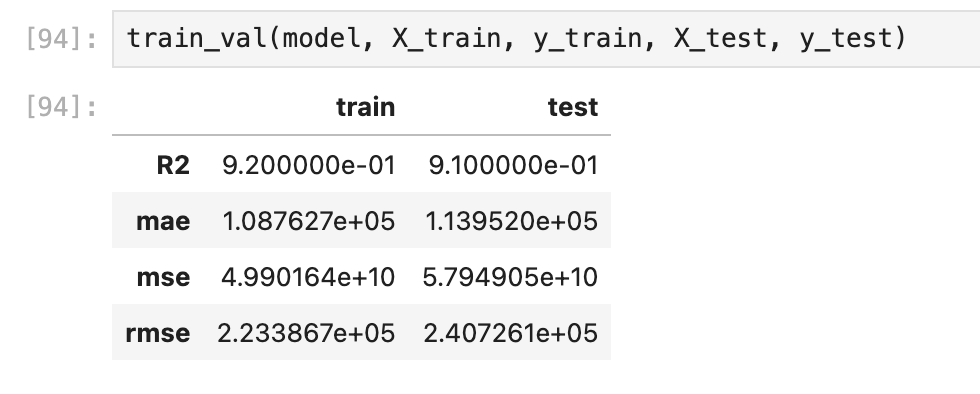

Our base model was way better than ridge!!!

In [119]:
# Make predictions
y_pred = ridge_grid_model.predict(X_test)

# Evaluation
rm_R2 = r2_score(y_test, y_pred)
rm_mae = mean_absolute_error(y_test, y_pred)
rm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))


# Get the best model found by GridSearchCV
best_ridge = ridge_grid_model.best_estimator_

# Extract the fitted Ridge estimator
ridge = best_ridge.named_steps['model']

# Get transformed feature names
feature_names = best_ridge.named_steps[
    'preprocessor'
].get_feature_names_out()

# Display coefficients
ridge_coefficients = pd.DataFrame(
    ridge.coef_,
    index=feature_names,
    columns=['Coef']
).sort_values('Coef')

ridge_coefficients

,Coef
cat__brand_Tata,-0.495135
cat__brand_Datsun,-0.429737
cat__brand_Chevrolet,-0.416205
cat__brand_Fiat,-0.285458
cat__brand_Mahindra,-0.196418
cat__brand_Ford,-0.169724
cat__brand_Renault,-0.164459
cat__brand_Volkswagen,-0.158550
cat__brand_Nissan,-0.128422
cat__brand_Skoda,-0.128133


`GridSearchCV` does not directly expose the coefficients of the model. However, after fitting, it stores the best-performing fitted model in the `best_estimator_` attribute. Since our best estimator is a Pipeline, we can access the fitted Ridge Regression model through the `model` step and extract its coefficients. Because categorical variables are transformed through encoding, we must also use the feature names generated by the preprocessor rather than the original `X.columns`.


In [120]:
# we will use it for model comparison at the end 
# Make predictions
y_pred = ridge_grid_model.predict(X_test)

# Evaluation
ridge_R2 = r2_score(y_test, y_pred)
ridge_mae = mean_absolute_error(y_test, y_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

## Lasso Regression with GridSearch to find the best alpha

In [121]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Declare the model
lasso_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Lasso(random_state=42))
    ]
)

# Define the hyperparameter space
param_grid = {
    'model__alpha': alpha_space
}

# Hyperparameter tuning
lasso_grid_model = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=10,
    n_jobs=-1
)

# Fit using the original training data
lasso_grid_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.000e...1, 1.000e+02])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity o

In [122]:
lasso_grid_model.best_params_

{'model__alpha': np.float64(0.01)}

In [123]:
train_val(lasso_grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,8.100000e-01,8.300000e-01
mae,1.475964e+05,1.513212e+05
mse,1.255174e+11,1.176921e+11
rmse,3.542843e+05,3.430628e+05


In [124]:
# we will use it for model comparison at the end
# Make predictions
y_pred = lasso_grid_model.predict(X_test)

# Evaluation
lasso_R2 = r2_score(y_test, y_pred)
lasso_mae = mean_absolute_error(y_test, y_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

The scores for lasso is even worse unfortunately!!

In [125]:
# Make predictions
y_pred = lasso_grid_model.predict(X_test)

# Evaluation
lm_R2 = r2_score(y_test, y_pred)
lm_mae = mean_absolute_error(y_test, y_pred)
lm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))


# Get the best model found by GridSearchCV
best_lasso = lasso_grid_model.best_estimator_

# Extract the fitted Lasso estimator
lasso = best_lasso.named_steps['model']

# Get transformed feature names
feature_names = best_lasso.named_steps[
    'preprocessor'
].get_feature_names_out()

# Display coefficients
lasso_coefficients = pd.DataFrame(
    lasso.coef_,
    index=feature_names,
    columns=['Coef']
).sort_values('Coef')

lasso_coefficients

,Coef
cat__brand_Tata,-0.272141
remainder__car_age,-0.119923
cat__seller_type_Individual,-0.051609
remainder__owner,-0.039536
num__km_driven,-0.002882
cat__brand_BMW,0.000000
num__mileage,0.000000
cat__transmission_Manual,-0.000000
cat__seller_type_Trustmark Dealer,0.000000
cat__seller_type_Dealer,0.000000


Lasso did a feature selection, and only use very few features

In [126]:
print(
    "Number of features removed by Lasso:",
    (lasso.coef_ == 0).sum()
)

Number of features removed by Lasso: 26


## Elastic Net with GridSearch to find the best alpha and l1_ratio

In [127]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

# Declare the model
elastic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', ElasticNet(random_state=42))
    ]
)

# Define the hyperparameter space
param_grid = {
    'model__alpha': alpha_space,
    'model__l1_ratio': [.25, .5, .7, .9, .95, .99, 1]
}

# Hyperparameter tuning
elastic_grid_model = GridSearchCV(
    estimator=elastic_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=10,
    n_jobs=-1
)

# Fit using the original training data
elastic_grid_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.000e...1, 1.000e+02]), 'model__l1_ratio': [0.25, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: i

In [128]:
elastic_grid_model.best_params_

{'model__alpha': np.float64(0.01), 'model__l1_ratio': 0.25}

In [129]:
train_val(elastic_grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,8.500000e-01,8.600000e-01
mae,1.375897e+05,1.408595e+05
mse,9.889357e+10,9.514511e+10
rmse,3.144735e+05,3.084560e+05


In [130]:
# We will use it for model comparison at the end
# Make predictions
y_pred = elastic_grid_model.predict(X_test)

# Evaluation
elastic_R2 = r2_score(y_test, y_pred)
elastic_mae = mean_absolute_error(y_test, y_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [131]:
# so the best model was our base model!!!

In [132]:
# Make predictions
y_pred = elastic_grid_model.predict(X_test)

# Evaluation
em_R2 = r2_score(y_test, y_pred)
em_mae = mean_absolute_error(y_test, y_pred)
em_rmse = np.sqrt(mean_squared_error(y_test, y_pred))


# Get the best model found by GridSearchCV
best_elastic = elastic_grid_model.best_estimator_

# Extract the fitted Elastic Net estimator
elastic = best_elastic.named_steps['model']

# Get transformed feature names
feature_names = best_elastic.named_steps[
    'preprocessor'
].get_feature_names_out()

# Display coefficients
elastic_coefficients = pd.DataFrame(
    elastic.coef_,
    index=feature_names,
    columns=['Coef']
).sort_values('Coef')

elastic_coefficients

,Coef
cat__brand_Tata,-0.331372
cat__brand_Chevrolet,-0.164404
remainder__car_age,-0.116013
cat__fuel_Petrol,-0.102618
cat__transmission_Manual,-0.062843
remainder__owner,-0.054223
cat__brand_Mahindra,-0.042672
cat__seller_type_Individual,-0.041665
cat__brand_Ford,-0.027247
num__km_driven,-0.014791


In [133]:
# A combination of ridge and lasso!!

# Model Comparison

In [134]:
# Store the evaluation metrics from all models
scores = {
    "Linear Regression": {
        "R2": linear_R2,
        "MAE": linear_mae,
        "RMSE": linear_rmse
    },

    "Ridge Regression": {
        "R2": ridge_R2,
        "MAE": ridge_mae,
        "RMSE": ridge_rmse
    },

    "Lasso Regression": {
        "R2": lasso_R2,
        "MAE": lasso_mae,
        "RMSE": lasso_rmse
    },

    "Elastic Net": {
        "R2": elastic_R2,
        "MAE": elastic_mae,
        "RMSE": elastic_rmse
    }
}

# Convert to DataFrame
scores = pd.DataFrame(scores).T

scores

,R2,MAE,RMSE
Linear Regression,0.911174,0.185472,0.244206
Ridge Regression,0.911143,0.185510,0.244249
Lasso Regression,0.883098,0.210574,0.280154
Elastic Net,0.898169,0.199191,0.261473


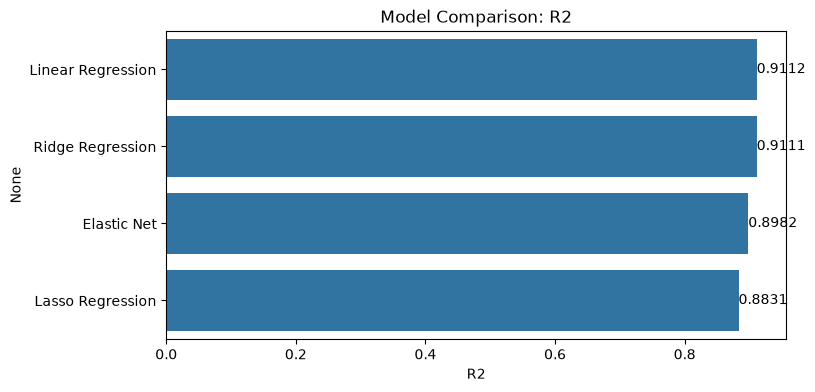

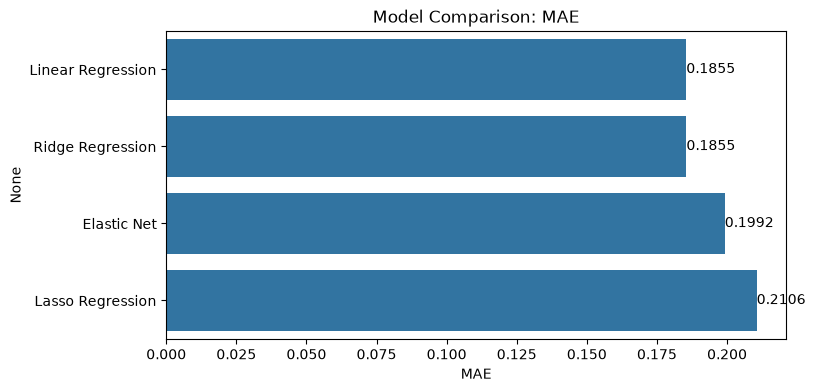

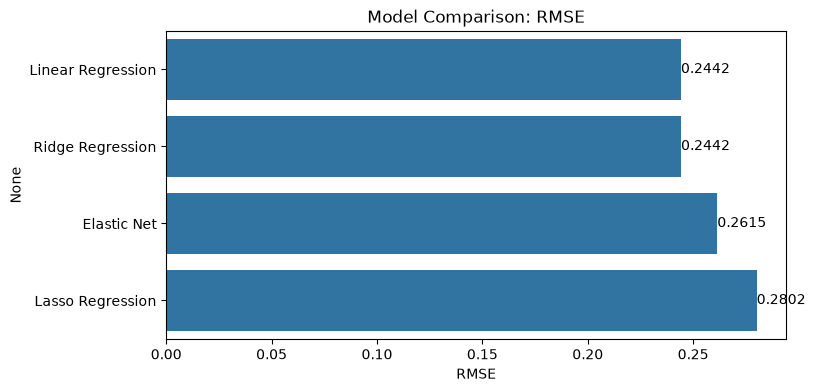

In [135]:
for metric in scores.columns:

    plt.figure(figsize=(8, 4))

    # Higher R2 is better, lower error metrics are better
    ascending = metric != "R2"

    compare = scores.sort_values(
        by=metric,
        ascending=ascending
    )

    ax = sns.barplot(
        x=compare[metric],
        y=compare.index
    )

    # Add values to bars
    for p in ax.patches:

        width = p.get_width()

        ax.text(
            width,
            p.get_y() + p.get_height() / 2,
            f'{width:.4f}',
            ha='left',
            va='center'
        )

    plt.title(f'Model Comparison: {metric}')
    plt.show()

In [136]:
## Now that we found the best model, which is linear regression model, that has no overfitting, and better scores than 
# ridge, lasso and elastic net, so let's train the final model on the entire dataset, and make some sample predictions!!

# Final Model

## For Test in Notebook

In [137]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Final Linear Regression pipeline
final_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Train on the entire dataset
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['brand','km_driven','fuel',...,'max_power','seats','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concat

In [138]:
# Now let's get a sample data from our dataset and use this final model to make prediction!!
df.head(1)

,brand,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
0,Maruti,450000,145500,Diesel,Individual,Manual,1,23.4,1248.0,74.0,5.0,12


In [139]:
# Take a random sample from the dataset!
sample_1 = df.sample(n=1)

# Remove the target column before prediction
sample_1_features = sample_1.drop(columns=['selling_price'])

# Predict the log selling price
prediction_log = final_model.predict(sample_1_features)

# Convert prediction back to the original price scale
prediction = np.exp(prediction_log)

# Compare actual and predicted prices
print("Actual Selling Price:", sample_1['selling_price'].iloc[0])
print("Predicted Selling Price:", prediction[0])

Actual Selling Price: 250000
Predicted Selling Price: 284879.72263416863


# Trying multiple regression model at the same time, to find a potential good model!!

In [140]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    HuberRegressor
)

from sklearn.tree import (
    DecisionTreeRegressor,
    ExtraTreeRegressor
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
    VotingRegressor
)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import (
    SVR,
    LinearSVR
)

from sklearn.neural_network import MLPRegressor


models = {
    
    # Linear Models
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Elastic Net": ElasticNet(),
    "Huber Regression": HuberRegressor(),
    
    
    # Tree Models
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Extra Tree": ExtraTreeRegressor(random_state=42),
    
    
    # Ensemble Models
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    
    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    
    "AdaBoost": AdaBoostRegressor(
        random_state=42
    ),
    
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    ),
    
    
    # Neighbors
    "KNN": KNeighborsRegressor(),
    
    
    # Support Vector Machines
    "SVR": SVR(),
    "Linear SVR": LinearSVR(
        random_state=42,
        max_iter=10000
    ),
    
    
    # Neural Network
    "ANN (MLP)": MLPRegressor(
        random_state=42,
        max_iter=1000
    )
}

In [141]:
results = {}

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features)
    ],
    remainder='passthrough'
)


for name, model in models.items():
    
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    results[name] = r2_score(y_test, y_pred)


results_df = pd.DataFrame(
    results.items(),
    columns=['Model', 'R2 Score']
)

results_df.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,R2 Score
11,Hist Gradient Boosting,0.944746
7,Random Forest,0.943456
8,Extra Trees,0.940618
9,Gradient Boosting,0.933674
15,ANN (MLP),0.930388
13,SVR,0.928910
12,KNN,0.919707
1,Ridge,0.911194
0,Linear Regression,0.911173
14,Linear SVR,0.908308


In [142]:
# These are some potential good models that can be tried !!

# Results and Discussion

The results of this project show that used car selling prices can be predicted with relatively high accuracy using the available vehicle characteristics. Before modelling, several important data cleaning and feature engineering decisions were made. The dataset was simplified by extracting the vehicle brand from the original name column, removing the `torque` feature, removing CNG and LPG vehicles because their mileage measurements use a different unit, and removing Test Drive Cars because their unusually high prices could distort the analysis. Rows containing missing values in `mileage`, `engine`, `max_power`, and `seats` represented approximately 2.59% of the dataset and were removed rather than imputing several potentially important variables simultaneously. 

Exploratory data analysis revealed that the target variable, `selling_price`, was strongly right-skewed and contained a number of very expensive vehicles. Therefore, a logarithmic transformation was applied to the target variable before training the models. This transformation compressed the range of selling prices, reduced the visual influence of extremely expensive vehicles, and made the relationships between the numerical variables and the target easier to observe. However, predictions were converted back using the exponential function when evaluating the main models in terms of actual selling prices, allowing the prediction errors to remain interpretable in the original currency scale. 

Feature engineering also played an important role in improving the dataset. The `car_age` feature was created from the manufacturing year, but this immediately introduced a perfect negative correlation of -1 with the original `year` variable because both features represented essentially the same information. Keeping both variables would introduce perfect multicollinearity and make the interpretation of regression coefficients more difficult. Therefore, `year` was removed and `car_age` was retained because vehicle age provides a more intuitive and directly interpretable representation of depreciation. In addition, the `brand` feature contained several categories with extremely small numbers of observations. Brands occurring fewer than 10 times were grouped into a `Rare Brands` category, reducing unnecessary categorical complexity while preserving the observations themselves. 

Among the features, **maximum power appears to be one of the most important predictors of selling price**. The coefficient analysis from the regularized models consistently showed `max_power` among the strongest positive numerical relationships with the target. Engine size also showed a positive relationship, although weaker than maximum power. On the other hand, `car_age` had a negative relationship with selling price, which is consistent with the expected depreciation of vehicles as they become older. `km_driven` also generally had a negative relationship, suggesting that vehicles with greater usage tend to have lower selling prices. The analysis also showed that mileage had a relatively weak contribution compared with features such as maximum power, engine size, vehicle age, and brand. However, feature importance should not be interpreted as a causal relationship, since several vehicle characteristics can be related to each other. 

Categorical variables were also important. The exploratory analysis showed substantial differences in average selling prices across fuel types, transmission types, seller types, ownership history, and especially brands. Diesel vehicles had a higher average selling price than petrol vehicles in the dataset, while automatic vehicles had a considerably higher average selling price than manual vehicles. Similarly, vehicles sold by dealers had higher average prices than vehicles sold by individuals, and vehicles with fewer previous owners generally had higher average selling prices. Brand also provided valuable information because luxury brands such as Lexus, BMW, Volvo, Jaguar, Mercedes-Benz, and Audi had considerably higher average selling prices than many mass-market brands. This indicates that selling price cannot be explained by numerical vehicle specifications alone; the vehicle's market segment and brand identity also contain useful predictive information. 

The initial Linear Regression model performed very well. When evaluated after converting the predictions back to the original selling-price scale, it achieved approximately **0.92 R² on the training data and 0.91 R² on the test data**. The small difference between training and test performance suggests that the model generalized reasonably well and did not show strong evidence of overfitting. The test MAE was approximately **113,952**, meaning that the average absolute prediction error was around this amount in the original selling-price scale. The test RMSE was approximately **240,726**, which was noticeably larger than the MAE. This indicates that although many predictions were reasonably close to the actual prices, the model occasionally made relatively large prediction errors. 

Cross-validation further supported the stability of the Linear Regression model. The average training and validation R² scores were both approximately **0.92**, while the MAE and RMSE remained very similar between the training and validation folds. This is an encouraging result because it suggests that the model's strong performance was not dependent on one particular train-test split. In other words, the model appears to have learned patterns that generalize across different subsets of the available data rather than simply performing well on the original training observations. 

The prediction error and residual analysis nevertheless showed an important limitation of the Linear Regression model. Some of the largest errors occurred for relatively expensive vehicles, where the predicted selling price differed substantially from the actual value. An IQR-based outlier analysis identified many high-priced vehicles, with an upper bound of approximately **1,332,500** and a considerable number of observations above this threshold. However, these vehicles were not automatically removed because they were likely genuine expensive vehicles rather than data errors. Removing hundreds of such observations would substantially change the distribution of the target variable and could make the final model less capable of predicting expensive cars. Instead, the logarithmic transformation was retained as a more appropriate way of reducing the influence of extreme prices while preserving the valuable observations. 

Regularized linear models were subsequently tested using GridSearchCV. Ridge Regression, with a best `alpha` value of **0.01**, performed extremely similarly to the original Linear Regression model but did not provide a meaningful improvement. This suggests that, after removing the perfect multicollinearity between `year` and `car_age`, the dataset did not suffer from a level of coefficient instability that required substantial regularization. In fact, the regularization slightly reduced predictive performance. Lasso Regression performed substantially worse than both Linear Regression and Ridge Regression. Its coefficient analysis showed that it shrank many variables to exactly zero, effectively performing automatic feature selection. While feature selection can sometimes improve generalization, in this case the removed variables apparently contained useful predictive information, causing the model to lose accuracy. 

Elastic Net Regression, which combines L1 and L2 regularization, performed better than Lasso but still worse than Linear Regression and Ridge Regression. The Elastic Net model also shrank many coefficients toward zero, although less aggressively than Lasso depending on the selected `l1_ratio`. These results suggest that the information contained across many features, including multiple brands and vehicle characteristics, is valuable for predicting selling price. Therefore, aggressively eliminating features was not beneficial for this particular dataset. Among the four main linear models tested, **Linear Regression was the best-performing model**, followed very closely by Ridge Regression, while Lasso and Elastic Net showed lower predictive performance. 

The later comparison involving a wider range of algorithms produced an even more interesting result. The highest R² score was achieved by **Hist Gradient Boosting (0.944746)**, followed closely by **Random Forest (0.943456)** and **Extra Trees (0.940618)**. Gradient Boosting also performed strongly with an R² of approximately **0.933674**, while the ANN (MLP) and SVR models achieved approximately **0.930388** and **0.928910**, respectively. In comparison, Linear Regression and Ridge achieved approximately **0.911**, demonstrating that several nonlinear models were able to extract additional predictive information from the dataset. 

A likely explanation for the strong performance of the tree-based ensemble models is that the exploratory analysis suggested that many relationships between the features and selling price were not purely linear. For example, the effect of maximum power, engine capacity, mileage, vehicle age, and kilometres driven may change at different values rather than increasing or decreasing at a constant rate. In addition, interactions are likely to exist between features. For example, the importance of engine size may be different for a luxury vehicle compared with an economy vehicle, and the effect of kilometres driven may depend on the age of the vehicle. Linear Regression cannot automatically capture such nonlinear relationships and interactions unless additional features are explicitly engineered. Tree-based ensemble methods, particularly boosting and random forests, are more capable of learning these complex patterns directly from the data.

The model comparison therefore provides an important conclusion: **Linear Regression was the strongest model among the manually tuned linear and regularized models, but nonlinear ensemble models demonstrated that the dataset contains additional patterns beyond a simple linear relationship.** Hist Gradient Boosting, Random Forest, and Extra Trees are particularly promising candidates for further experimentation. However, these results should be interpreted carefully because the broad model comparison was performed primarily as an initial exploration of potential algorithms, and the models were not all extensively hyperparameter tuned. Therefore, the higher R² scores show promising potential rather than proving that these models are already fully optimized. 

Overall, this project demonstrates that vehicle selling prices can be predicted effectively using characteristics such as **maximum power, engine size, vehicle age, ownership history, kilometres driven, fuel type, transmission, seller type, and brand**. Maximum power, vehicle age, and brand appear particularly influential, while some variables such as mileage and the number of seats appear to provide less predictive information relative to the strongest features. The Linear Regression model provided an excellent and interpretable baseline with stable training, testing, and cross-validation performance. However, the superior performance of Hist Gradient Boosting, Random Forest, and Extra Trees suggests that nonlinear relationships and feature interactions are important in this problem. A logical next step would therefore be to perform proper hyperparameter tuning and cross-validation on the strongest tree-based models, evaluate all final models consistently on the original selling-price scale, and investigate additional feature engineering. This could potentially improve prediction accuracy beyond the already strong baseline established in this project.


## Ready for Deployment

In [143]:
# ============================================================
# FINAL DEPLOYMENT-READY MODEL
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import joblib


# ------------------------------------------------------------
# 1. Define feature groups
# ------------------------------------------------------------

numerical_features = [
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'car_age',
    'seats',
    'owner'
]

categorical_features = [
    'brand',
    'fuel',
    'seller_type',
    'transmission'
]


# ------------------------------------------------------------
# 2. Numerical preprocessing
# ------------------------------------------------------------

numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)


# ------------------------------------------------------------
# 3. Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# 4. Combine preprocessing steps
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


# ------------------------------------------------------------
# 5. Final Linear Regression pipeline
# ------------------------------------------------------------

final_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)


# ------------------------------------------------------------
# 6. Train on the entire dataset
# ------------------------------------------------------------

final_model.fit(X, y)

print("Final deployment model trained successfully!")


# ------------------------------------------------------------
# 7. Save the complete pipeline
# ------------------------------------------------------------

joblib.dump(final_model, 'car_price_model.pkl')

print("Model saved successfully as car_price_model.pkl")

Final deployment model trained successfully!
Model saved successfully as car_price_model.pkl


In [144]:
# Load the saved model
loaded_model = joblib.load('car_price_model.pkl')


# Test with some missing values
sample_input = pd.DataFrame({
    
    "brand": ["Maruti"],
    "fuel": ["Diesel"],
    "seller_type": ["Individual"],
    "transmission": ["Manual"],

    "km_driven": [50000],
    "mileage": [None],
    "engine": [1248],
    "max_power": [None],

    "car_age": [5],
    "seats": [None],
    "owner": [None]

})


# Make prediction
prediction_log = loaded_model.predict(sample_input)

# Convert back from log scale
prediction = np.exp(prediction_log[0])

print("Predicted Selling Price:", prediction)

Predicted Selling Price: 1060128.916140728


# <p style="background-color:green;font-family:newtimeroman;font-size:100%;color:white;text-align:center;border-radius:20px 20px;"><b>Thanks</b></p>